
  ISOTHERMAL (V6.7.5)
  Auto-size (gas flooding): D = 29 cm, u_G = 14.7 cm/s, flood = 65.1%, liq load = 36.3 m³/(m²·h)
  ✓ kG·a_w = 2.585 mol/(m³·s·atm) — in expected range

  Bracket found: [0.000234, 0.000263]  resid = [-1.965e-05, 9.166e-06]

  BVP converged:
    C_DIC(z=0, bottom) = 0.000254 mol/L
    C_DIC(z=Z, top)    = -2.72e-12 mol/L  (target = 0.0)
    The solver successfully reached the end of the integration interval.

  ABSORBER SUMMARY — Absorber (V6.7.5)
  --- Geometry & Flow ---
  Column diameter    : 29.0 cm  (auto)
  Packed height      : 15.00 m
  Area               : 660.5 cm²
  u_G                : 14.719 cm/s
  u_L                : 10.0931 mm/s
  Liq load           : 36.3 m³/(m²·h)  (max 40)
  L/G molar          : 91.55
  GHSV               : 35.3 h⁻¹
  Packing            : custom (structured)
  d_h                : 15.5 mm
  h_L                : 0.0905
  ε_eff (ε−h_L)      : 0.8795
  --- Wetted Area ---
  a_p                : 250 m²/m³
  a_w                : 162.3

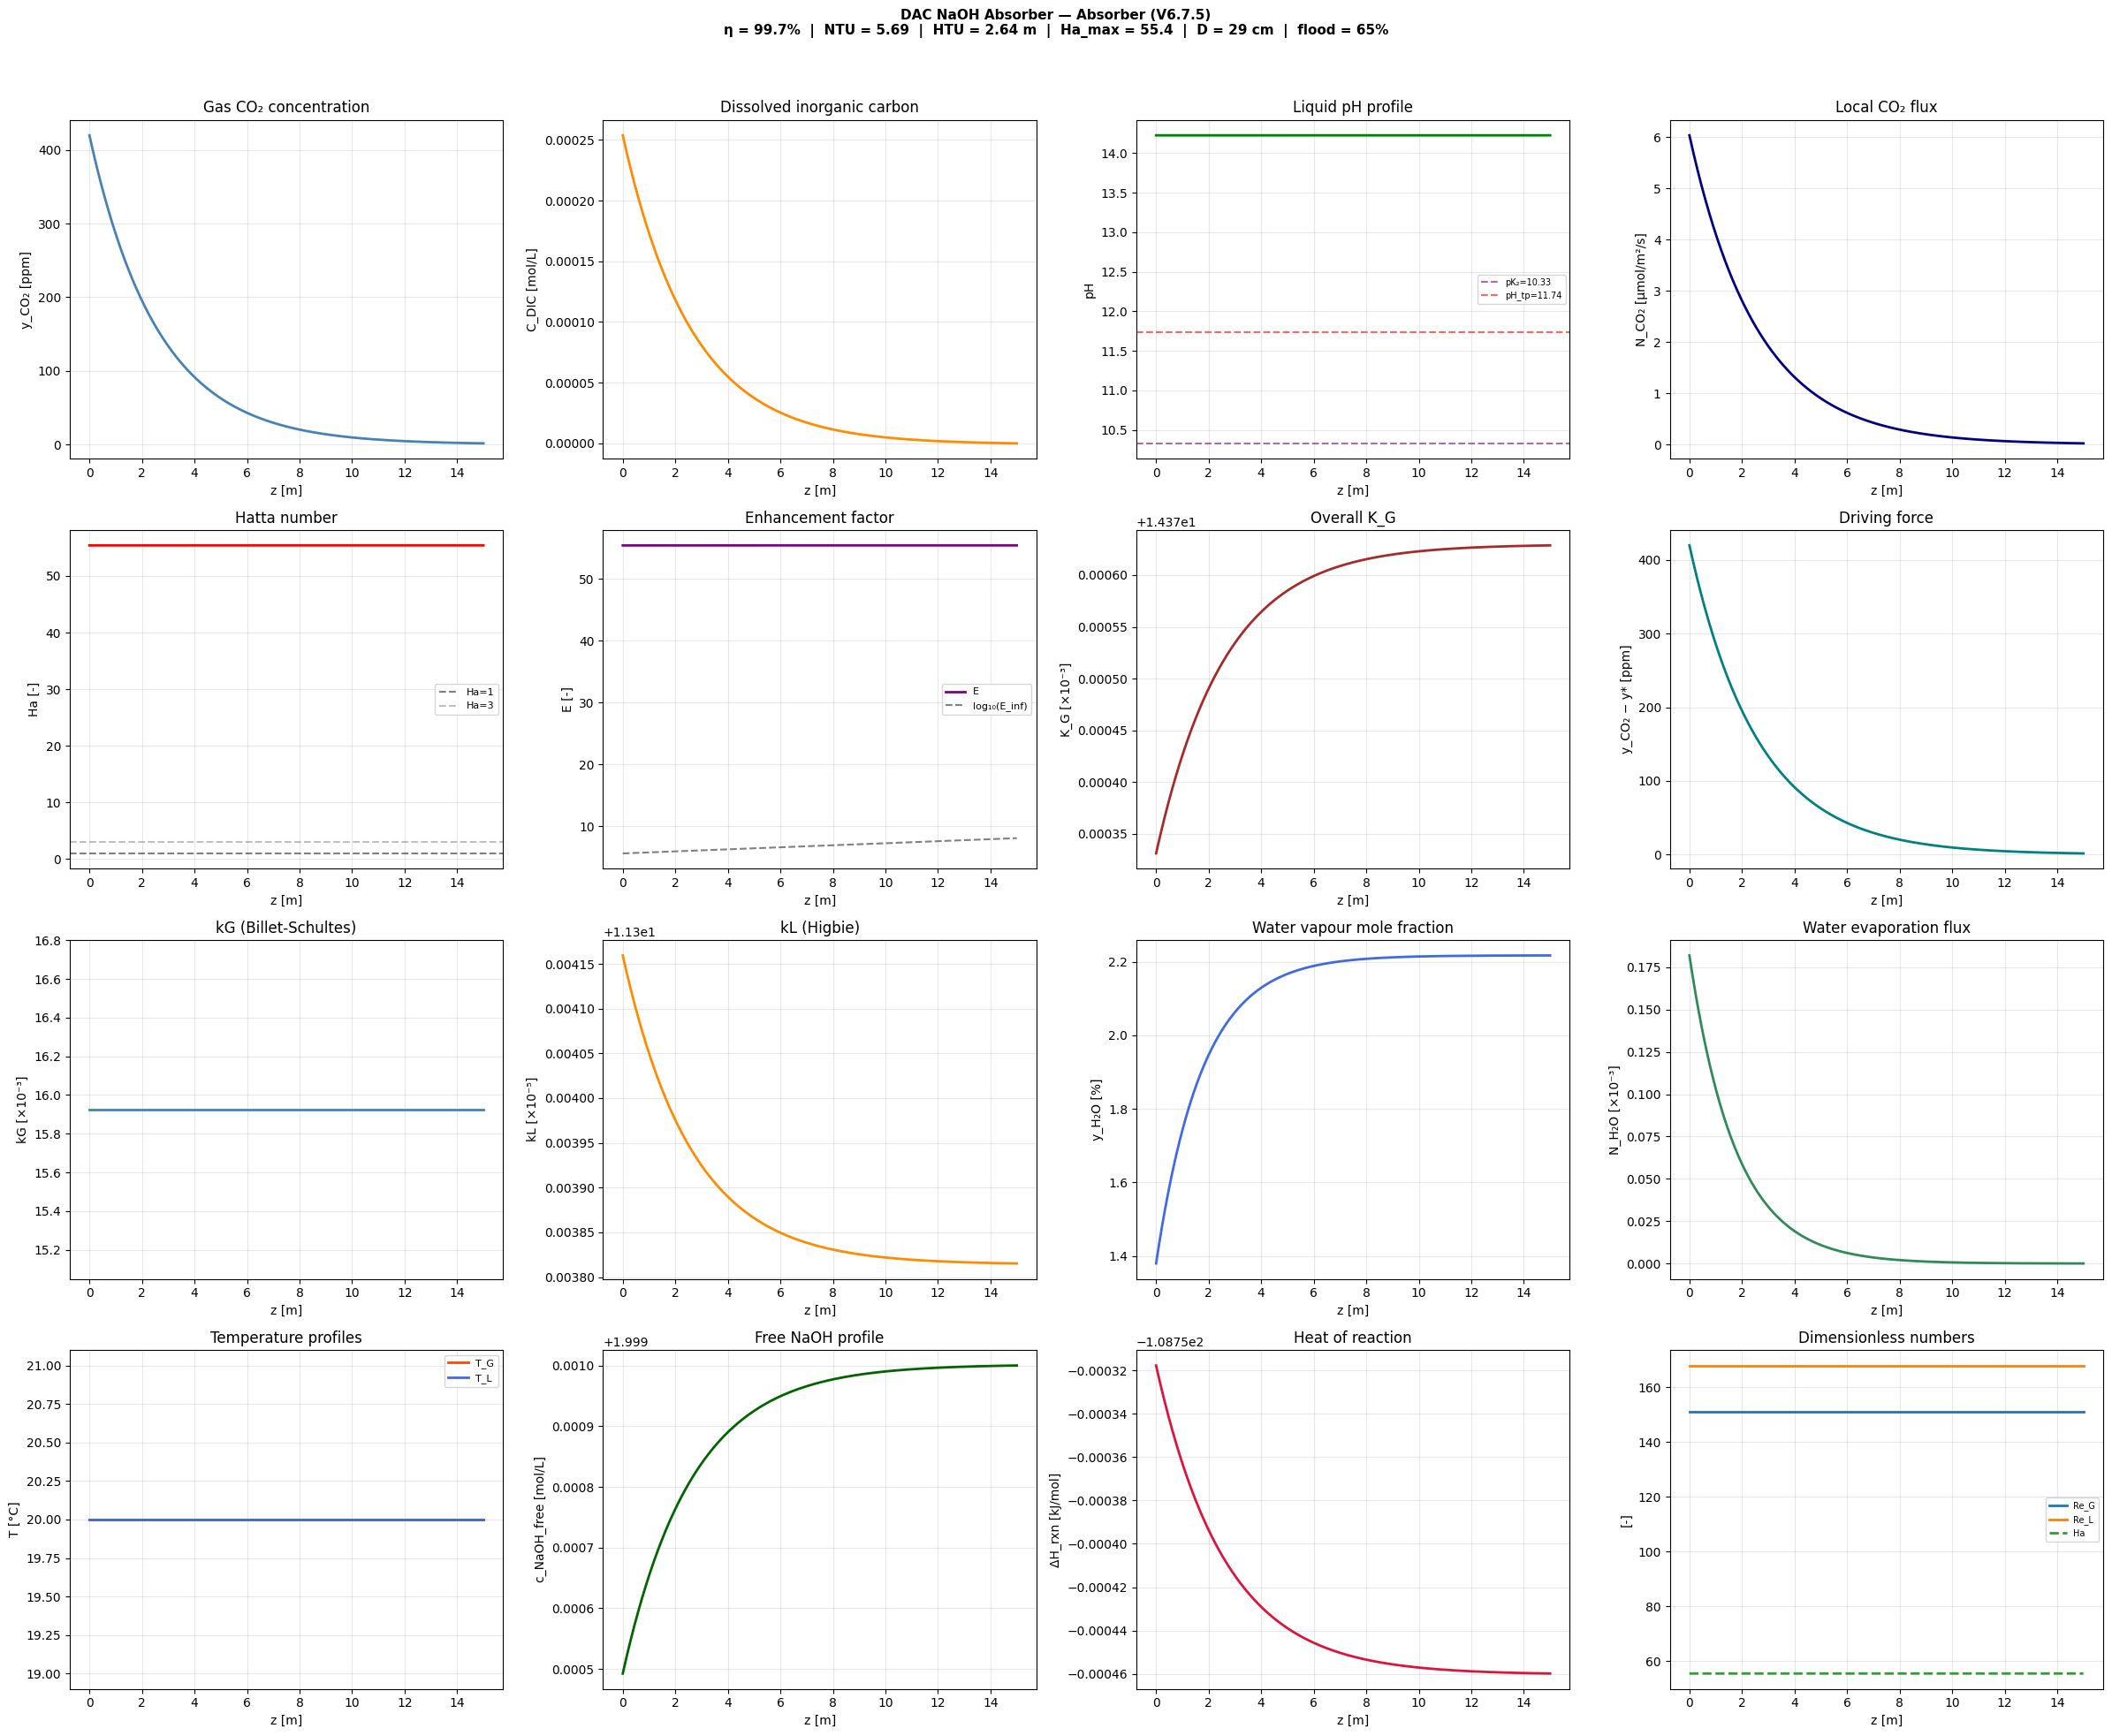


  ADIABATIC (V6.7.5)
  Auto-size (gas flooding): D = 29 cm, u_G = 14.7 cm/s, flood = 65.1%, liq load = 36.3 m³/(m²·h)
  ✓ kG·a_w = 2.585 mol/(m³·s·atm) — in expected range

  Adiabatic BVP (V6.7.5)...
  Step 1: isothermal warm start...
  ✓ kG·a_w = 2.585 mol/(m³·s·atm) — in expected range

  Bracket found: [0.000234, 0.000263]  resid = [-1.965e-05, 9.166e-06]

  BVP converged:
    C_DIC(z=0, bottom) = 0.000254 mol/L
    C_DIC(z=Z, top)    = -2.72e-12 mol/L  (target = 0.0)
    The solver successfully reached the end of the integration interval.
  Warm start: C_DIC_bot = 0.000254
  Step 2: multi-start fsolve...

  Converged (norm=4.037e-21):
    C_DIC(0)=0.000254, T_L(0)=19.95°C
    C_DIC(Z)=4.04e-21, T_L(Z)=20.00°C
    The solver successfully reached the end of the integration interval.

  ABSORBER SUMMARY — AdiabaticAbsorber (V6.7.5)
  --- Geometry & Flow ---
  Column diameter    : 29.0 cm  (auto)
  Packed height      : 15.00 m
  Area               : 660.5 cm²
  u_G                : 1

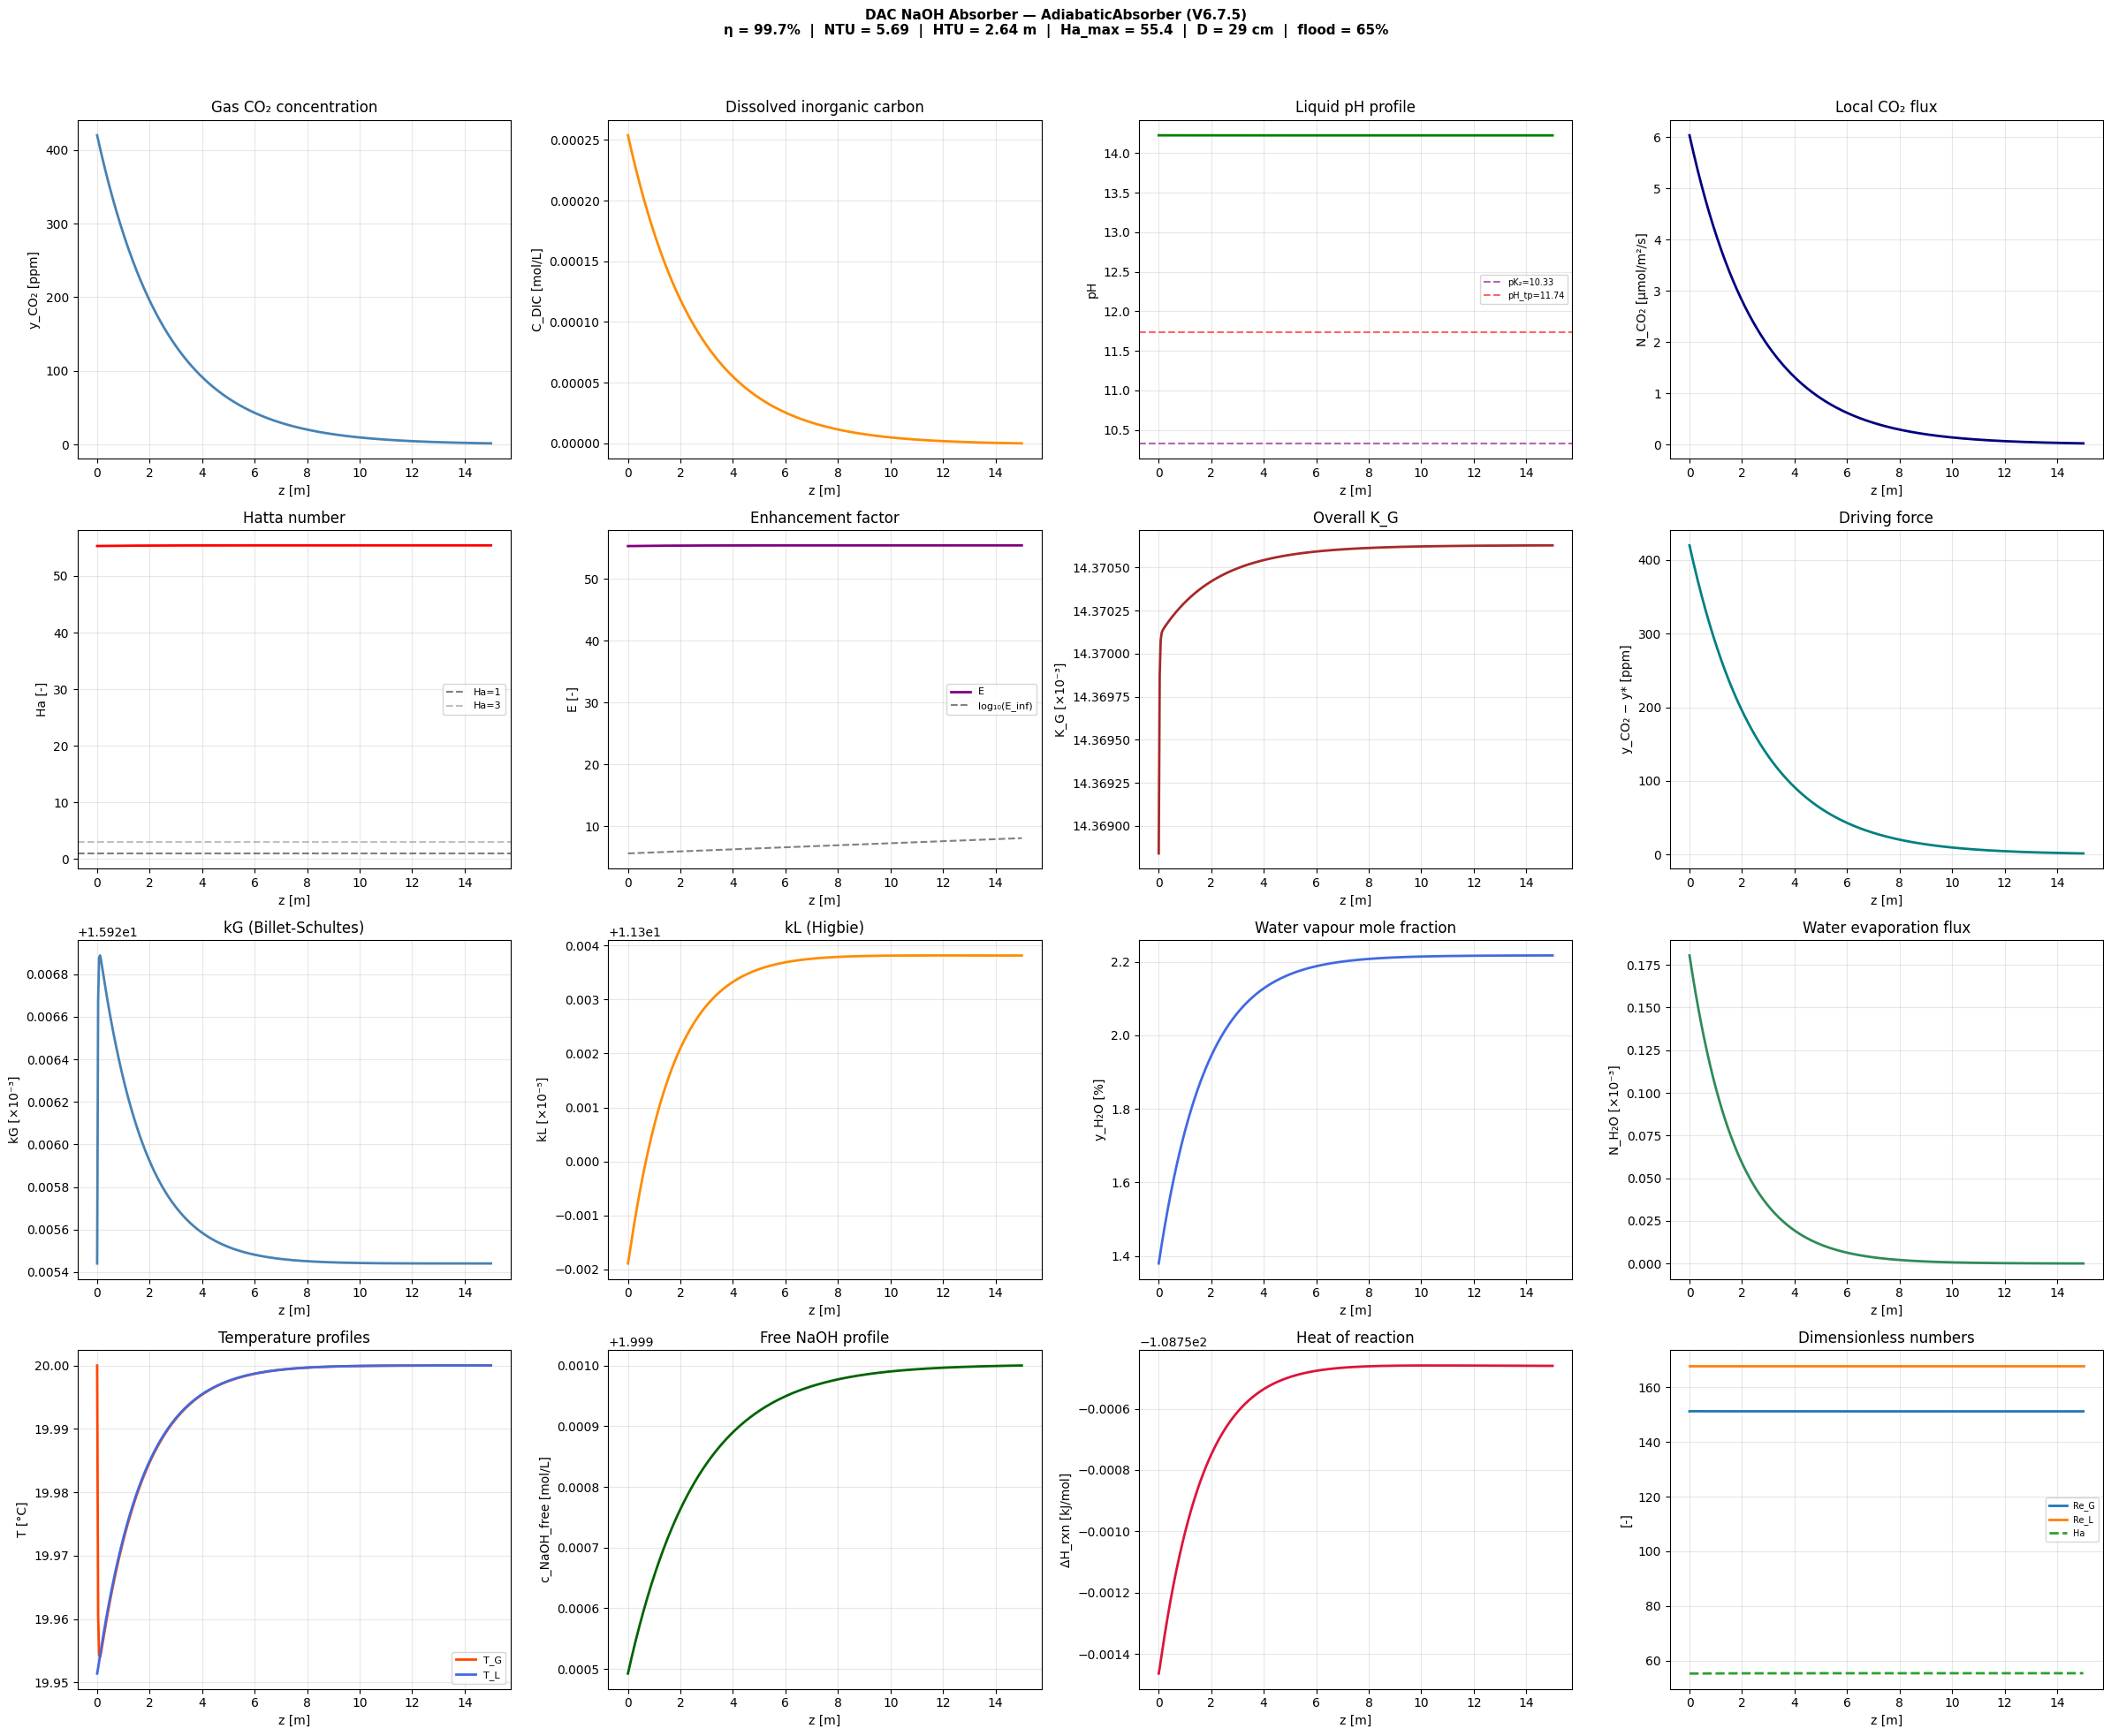

In [ ]:
"""
=============================================================================
 1D Counter-Current NaOH Packed Absorber — Direct Air Capture of CO2
 CLASS-BASED MODEL
=============================================================================

 Sources:
  - Seithümmer et al. (2025) Chem. Ing. Tech. 97(5), 554-559
  - Ghaffari et al.   (2023) Ind. Eng. Chem. Res. 62(19), 7566-7579
  - Knuutila et al.   (2010) Chem. Eng. Sci. 65, 6077-6088
  - Sander             (2015) Atmos. Chem. Phys.
  - Millero            (1995) Carbonate equilibria
  - Billet & Schultes  (1999) Packed column hydraulics
  - Onda et al.        (1968) Wetted area correlation
  - Pohorecki & Moniuk (2001) k_OH kinetics
=============================================================================
"""

import datetime
import pickle
import random
import warnings

import numpy as np
from scipy.integrate import solve_ivp, trapezoid, simpson
from scipy.optimize import brentq, fsolve
from scipy.constants import R


# =============================================================================
# PACKING DATABASE
# =============================================================================

PACKING_DB = {
    "Mellapak 250Y": (250, 0.97, 0.016, 0.876, 0.604, 0.0338, 1.334,
                       0.075, "structured", 40.0, 0.012, 45),
    "Mellapak 500Y": (500, 0.97, 0.008, 0.876, 0.545, 0.0338, 1.334,
                       0.075, "structured", 25.0, 0.006, 45),
    "Mellapak 125Y": (125, 0.97, 0.032, 0.876, 0.700, 0.0338, 1.334,
                       0.075, "structured", 60.0, 0.024, 45),
    "Sulzer BX":     (492, 0.90, 0.017, 0.700, 0.450, 0.0260, 1.210,
                       0.075, "structured", 20.0, 0.009, 60),
    "Pall 25mm":     (220, 0.94, 0.025, 2.450, 0.336, 0.0410, 1.012,
                       0.075, "random", 80.0, None, None),
    "Pall 50mm":     (112, 0.95, 0.050, 2.816, 0.410, 0.0410, 1.012,
                       0.075, "random", 120.0, None, None),
}


def _plot(ax, x, y, color, ylabel, title):
    ax.plot(x, y, color=color, lw=2)
    ax.set_xlabel("z [m]")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid(True, alpha=0.3)


class Absorber:
    """
    1D steady-state counter-current packed absorber for CO2-NaOH DAC.

    Convention
    ----------
    z = 0 : column bottom  (gas inlet,  liquid outlet)
    z = Z : column top     (gas outlet, liquid inlet)
    Gas flows +z (upward), Liquid flows -z (downward).
    """

    WETTING_RATE_THRESHOLD = 0.01e-3
    P_TOTAL = 101_325.0
    LATENT_HEAT = 2_450e3
    MW = 0.018015
    MC = 0.04401
    MA = 0.02897

    def __init__(
        self,
        Z=15.0,
        D_col=None,
        D_min=0.15,
        u_G_max=2.0,
        flood_fraction=0.70,
        min_flood_fraction=0.40,
        a_p=250.0,
        epsilon=0.97,
        d_p=0.016,
        C_h=0.876,
        C_v=0.604,
        C_BG=0.0338,
        C_BL=1.334,
        sigma_c=0.075,
        packing_type="structured",
        packing_name=None,
        max_liq_load=40.0,
        crimp_height=0.012,
        channel_angle=45,
        y_CO2_in=420e-6,
        T_G_in=293.15,
        G_vol=35.0,
        RH_in=0.60,
        c_NaOH_in=2.0,
        C_DIC_top=0.0,
        T_L_in=293.15,
        L_vol_flow=40.0,
        kG_override=None,
        kL_override=None,
        kL_model="Higbie",
        mu_G=1.81e-5,
        rho_G_ref=None,
        M_air=0.02897,
        mu_L=1.0e-3,
        rho_L=1040.0,
        sigma_L=0.072,
        M_L=0.018,
        disc_z=401,
        design_mode=False,
        target_NaOH_utilization=0.30,
    ):
        if packing_name and packing_name in PACKING_DB:
            pk = PACKING_DB[packing_name]
            a_p, epsilon, d_p = pk[0], pk[1], pk[2]
            C_h, C_v, C_BG, C_BL = pk[3], pk[4], pk[5], pk[6]
            sigma_c, packing_type = pk[7], pk[8]
            max_liq_load = pk[9]
            crimp_height = pk[10]
            channel_angle = pk[11]

        self.Z = Z
        self.a_p = a_p
        self.epsilon = epsilon
        self.d_p = d_p
        self.C_h = C_h
        self.C_v = C_v
        self.C_BG = C_BG
        self.C_BL = C_BL
        self.sigma_c = sigma_c
        self.flood_fraction = flood_fraction
        self.min_flood_fraction = min_flood_fraction
        self.packing_type = packing_type
        self.packing_name = packing_name or "custom"
        self.max_liq_load = max_liq_load
        self.crimp_height = crimp_height
        self.channel_angle = channel_angle
        self.D_min = D_min
        self.u_G_max = u_G_max

        self.y_CO2_in = y_CO2_in
        self.T_G_in = T_G_in
        self.G_vol = G_vol
        self.RH_in = RH_in

        # --- Fix #5: single alkali inventory ---
        self.c_NaOH_in = c_NaOH_in
        self.c_Na_tot = c_NaOH_in

        # --- Fix #6: removed dead C_DIC_in; C_DIC_top is the sole BC ---
        self.C_DIC_top = C_DIC_top

        self.T_L_in = T_L_in
        self.L_vol_flow = L_vol_flow

        self.kG_override = kG_override
        self.kL_override = kL_override
        self.kL_model = kL_model

        self.mu_G_ref = mu_G
        self.M_air = M_air

        self.mu_L = mu_L
        self.rho_L = rho_L
        self.sigma_L = sigma_L
        self.M_L = M_L

        self.disc_z = disc_z
        self._is_adiabatic = False

        # --- Fix #8: convergence flag ---
        self.bvp_converged = False

        if design_mode:
            self.L_vol_flow = self._design_liquid_flow(target_NaOH_utilization)

        if rho_G_ref is None:
            self.rho_G_ref = self.P_TOTAL * self.MA / (R * self.T_G_in)
        else:
            self.rho_G_ref = rho_G_ref

        self.y_H2O_in = self.RH_in * self.p_sat_water(self.T_G_in) / self.P_TOTAL
        denom_in = max(1.0 - self.y_CO2_in - self.y_H2O_in, 1e-20)
        self.Y_CO2_in = self.y_CO2_in / denom_in
        self.Y_H2O_in = self.y_H2O_in / denom_in

        if D_col is None:
            self.D_col = self._auto_size_diameter()
            self._auto_sized = True
        else:
            self.D_col = D_col
            self._auto_sized = False

        self.A_col = np.pi / 4.0 * self.D_col ** 2
        self.V_col = self.A_col * self.Z
        self.d_h = 4.0 * self.epsilon / self.a_p

        rho_G_mol = self.P_TOTAL / (R * self.T_G_in)
        self.G_mol = (self.G_vol / 3600.0) * rho_G_mol / self.A_col
        self.G_inert = self.G_mol * (1.0 - self.y_CO2_in - self.y_H2O_in)

        L_vol_SI = self.L_vol_flow / 60.0 / 1000.0
        self.L_mol = L_vol_SI * 55500.0 / self.A_col
        self.L_vol_flux = L_vol_SI / self.A_col * 1000.0

        self.u_G = (self.G_vol / 3600.0) / self.A_col
        self.u_L = L_vol_SI / self.A_col
        self.liq_load = self.u_L * 3600.0

        self.LHSV = L_vol_SI / self.V_col
        self.GHSV = (self.G_vol / 3600.0) / self.V_col

        self.h_L = self._liquid_holdup()

        self.kG_BS, self.kL_detail = self._compute_kG_kL(
            self.T_G_in, self.T_L_in, self.c_NaOH_in
        )
        self.kG = self.kG_BS if self.kG_override is None else self.kG_override
        self.kL = self._select_kL(self.kL_detail)
        if self.kL_override is not None:
            self.kL = self.kL_override

        self.a_w = self._compute_wetted_area()

        self.l_eval = np.linspace(1e-4, self.Z, self.disc_z)
        self.l_span = np.array([self.l_eval[0], self.l_eval[-1]])
        self.Zeta = self.l_eval / self.Z

        self._init_arrays()
        self._validate_kG()

    # -----------------------------------------------------------------
    def _init_arrays(self):
        n = self.disc_z
        self.y_CO2 = np.zeros(n)
        self.Y_CO2 = np.zeros(n)
        self.C_DIC = np.zeros(n)
        self.y_H2O = np.full(n, self.y_H2O_in)
        self.Y_H2O = np.full(n, self.Y_H2O_in)
        self.T_G = np.full(n, self.T_G_in)
        self.T_L = np.full(n, self.T_L_in)
        self.pH = np.zeros(n)
        self.Ha = np.zeros(n)
        self.E = np.zeros(n)
        self.E_inf = np.zeros(n)
        self.KG = np.zeros(n)
        self.N_CO2 = np.zeros(n)
        self.N_H2O = np.zeros(n)
        self.y_star = np.zeros(n)
        self.dH_rxn = np.zeros(n)
        self.c_NaOH_free = np.zeros(n)
        self.kG_profile = np.zeros(n)
        self.kL_profile = np.zeros(n)
        self.u_L_profile = np.full(n, self.u_L)
        self.Re_G = np.zeros(n)
        self.Re_L = np.zeros(n)
        self.Sc_G = np.zeros(n)
        self.Sc_L = np.zeros(n)
        self.Sh_G = np.zeros(n)
        self.Pe_ax = np.zeros(n)
        self.NTU = np.nan
        self.HTU = np.nan
        self.Q_rxn_total = 0.0
        self.Q_GL_total = 0.0
        self.Q_evap_total = 0.0

    def __repr__(self):
        return (
            f"Absorber(Z={self.Z}m, D={self.D_col*100:.0f}cm, "
            f"a_p={self.a_p}, G={self.G_vol}m3/h, "
            f"L={self.L_vol_flow:.2f}L/min, NaOH={self.c_Na_tot}M)"
        )

    # -----------------------------------------------------------------
    #  Design mode
    # -----------------------------------------------------------------
    def _design_liquid_flow(self, target_util):
        rho_mol = self.P_TOTAL / (R * self.T_G_in)
        n_CO2_max = (self.G_vol / 3600.0) * rho_mol * self.y_CO2_in
        eta_est = min(0.95, 1.0 - np.exp(-self.Z / 3.0))
        n_CO2_est = eta_est * n_CO2_max
        L_mol_s = 2.0 * n_CO2_est / (self.c_NaOH_in * target_util)
        L_Lmin = L_mol_s / 55.5 * 1000.0 * 60.0
        L_Lmin = max(L_Lmin, 0.01)
        print(f"  Design mode: L = {L_Lmin:.3f} L/min "
              f"(target {target_util*100:.0f}% NaOH util, "
              f"eta_est = {eta_est*100:.0f}%)")
        return L_Lmin

    # -----------------------------------------------------------------
    #  Ratio helpers
    # -----------------------------------------------------------------
    @staticmethod
    def _Y_to_y(Y_CO2, Y_H2O):
        denom = 1.0 + Y_CO2 + Y_H2O
        return Y_CO2 / denom, Y_H2O / denom

    @staticmethod
    def _y_to_Y(y_CO2, y_H2O):
        denom = max(1.0 - y_CO2 - y_H2O, 1e-20)
        return y_CO2 / denom, y_H2O / denom

    # -----------------------------------------------------------------
    #  Physical properties — gas phase
    # -----------------------------------------------------------------
    def density_gas(self, T):
        return self.P_TOTAL * self.MA / (R * T)

    def viscosity_gas(self, T):
        T_ref = 291.15
        S = 120.0
        return self.mu_G_ref * (T / T_ref) ** 1.5 * (T_ref + S) / (T + S)

    def diffusivity_CO2_in_air(self, T):
        P_atm = self.P_TOTAL / 101325.0
        return (
            1e-4 * 1e-3 * T ** 1.75
            * np.sqrt(1.0 / 44.0 + 1.0 / 29.0)
            / (P_atm * (26.9 ** (1.0/3.0) + 19.7 ** (1.0/3.0)) ** 2)
        )

    def diffusivity_H2O_in_air(self, T):
        P_atm = self.P_TOTAL / 101325.0
        return (
            1e-4 * 1e-3 * T ** 1.75
            * np.sqrt(1.0 / 18.0 + 1.0 / 29.0)
            / (P_atm * (13.1 ** (1.0/3.0) + 19.7 ** (1.0/3.0)) ** 2)
        )

    def p_sat_water(self, T):
        TC = T - 273.15
        if TC <= 100.0:
            A, B, C = 8.07131, 1730.63, 233.426
        else:
            A, B, C = 8.14019, 1810.94, 244.485
        return 10.0 ** (A - B / (C + TC)) * 133.322

    def p_sat_over_NaOH(self, T, c_NaOH):
        rho_kgL = self.rho_L / 1000.0
        m = max(c_NaOH, 0.0) / max(rho_kgL - max(c_NaOH, 0.0) * 0.040, 0.5)
        aw = max(1.0 - 0.017 * m, 0.5)
        return aw * self.p_sat_water(T)

    def water_evap_flux(self, T_L, T_G, y_H2O, c_NaOH, kG_H2O):
        y_sat = self.p_sat_over_NaOH(T_L, c_NaOH) / self.P_TOTAL
        return kG_H2O * (self.P_TOTAL / 101325.0) * (y_sat - y_H2O)

    # -----------------------------------------------------------------
    #  Holdup & void
    # -----------------------------------------------------------------
    def _liquid_holdup(self):
        g = 9.81
        return (
            12.0 * self.mu_L * self.u_L * self.a_p ** 2
            / (self.rho_L * g)
        ) ** (1.0 / 3.0)

    def _effective_void(self):
        return max(self.epsilon - self.h_L, 0.01)

    # -----------------------------------------------------------------
    #  Mass-transfer coefficients
    # -----------------------------------------------------------------
    def _compute_kG_kL(self, T_G, T_L, c_NaOH):
        mu_G = self.viscosity_gas(T_G)
        rho_G = self.density_gas(T_G)
        D_G = self.diffusivity_CO2_in_air(T_G)
        D_L = self.diffusivity_CO2_liquid(T_L, c_NaOH)
        eps = self.epsilon
        hL = self.h_L if hasattr(self, 'h_L') else (
            12.0 * self.mu_L * self.u_L * self.a_p ** 2
            / (self.rho_L * 9.81)
        ) ** (1.0 / 3.0)
        d_h = 4.0 * eps / self.a_p

        Re_G = rho_G * self.u_G * d_h / mu_G
        Sc_G = mu_G / (rho_G * D_G)
        kG_BS_ms = (
            self.C_BG
            * np.sqrt(self.a_p / max(eps - hL, 0.01))
            * D_G
            * (Re_G / eps) ** 0.75
            * Sc_G ** (1.0 / 3.0)
        )
        kG_BS = kG_BS_ms * self.P_TOTAL / (R * T_G)

        u_L_eff = self.u_L / max(eps * hL, 1e-10)

        kL_BS = self.C_BL * np.sqrt(D_L / d_h) * np.sqrt(max(u_L_eff, 1e-8))

        tau_exp = max(d_h / max(u_L_eff, 1e-8), 0.001)
        kL_Higbie = 2.0 * np.sqrt(D_L / (np.pi * tau_exp))

        g = 9.81
        Re_L_onda = self.rho_L * self.u_L / (self.mu_L * self.a_p)
        Sc_L = self.mu_L / (self.rho_L * D_L)
        kL_Onda = (
            0.0051
            * Re_L_onda ** (2.0 / 3.0)
            * Sc_L ** (-0.5)
            * (self.a_p * self.d_p) ** 0.4
            * (self.mu_L * g / self.rho_L) ** (1.0 / 3.0)
        )

        kL_detail = {"BS": kL_BS, "Higbie": kL_Higbie, "Onda": kL_Onda}
        return max(kG_BS, 1e-6), kL_detail

    def _select_kL(self, detail):
        if self.kL_model == "BS":
            return detail["BS"]
        elif self.kL_model == "Higbie":
            return detail["Higbie"]
        elif self.kL_model == "Onda":
            return detail["Onda"]
        elif self.kL_model == "min":
            return min(detail.values())
        elif self.kL_model == "mean":
            return np.mean(list(detail.values()))
        return detail["Higbie"]

    def _validate_kG(self):
        kGa = self.kG * self.a_w
        if kGa < 0.1:
            print(f"  ⚠ kG·a_w = {kGa:.3f} mol/(m³·s·atm) — very low")
        elif kGa > 10:
            print(f"  ⚠ kG·a_w = {kGa:.3f} mol/(m��·s·atm) — very high")
        else:
            print(f"  ✓ kG·a_w = {kGa:.3f} mol/(m³·s·atm) — in expected range")

    # --- Fix #2: overrides are now true absolute constants ---
    def _get_local_kG_kL(self, T_G, T_L, c_NaOH):
        if self.kG_override is not None:
            kG_loc = self.kG_override
        else:
            kG_loc, _ = self._compute_kG_kL(T_G, T_L, c_NaOH)

        if self.kL_override is not None:
            kL_loc = self.kL_override
        else:
            _, kL_d = self._compute_kG_kL(T_G, T_L, c_NaOH)
            kL_loc = self._select_kL(kL_d)

        # If neither is overridden, compute both in one call
        if self.kG_override is None and self.kL_override is None:
            kG_loc, kL_d = self._compute_kG_kL(T_G, T_L, c_NaOH)
            kL_loc = self._select_kL(kL_d)

        return kG_loc, kL_loc

    # -----------------------------------------------------------------
    #  Column auto-sizing
    # -----------------------------------------------------------------
    def _auto_size_diameter(self):
        g = 9.81
        G_vol_SI = self.G_vol / 3600.0
        L_vol_SI = self.L_vol_flow / 60.0 / 1000.0
        rho_G = self.rho_G_ref
        eps = self.epsilon

        D_gas = 0.50
        for _ in range(25):
            A = np.pi / 4.0 * D_gas ** 2
            u_L_iter = L_vol_SI / A
            hL_iter = (
                12.0 * self.mu_L * u_L_iter * self.a_p ** 2
                / (self.rho_L * g)
            ) ** (1.0 / 3.0)
            eps_eff = max(eps - hL_iter, 0.01)

            G_mol_loc = G_vol_SI * (self.P_TOTAL / (R * self.T_G_in)) / A
            L_mol_loc = L_vol_SI * 55500.0 / A
            F_lv = (
                (L_mol_loc * self.M_L / max(G_mol_loc * self.MA, 1e-20))
                * np.sqrt(rho_G / self.rho_L)
            )
            u_G_flood = self.C_v * (
                (g * eps_eff ** 3) / (self.a_p * (rho_G / self.rho_L))
            ) ** 0.5 * np.exp(-1.463 * F_lv ** 0.842)

            u_G_design = self.flood_fraction * u_G_flood
            D_new = np.sqrt(4.0 * G_vol_SI / (np.pi * max(u_G_design, 1e-6)))
            if abs(D_new - D_gas) < 1e-4:
                break
            D_gas = 0.5 * (D_gas + D_new)
        D_gas = np.ceil(D_new * 100.0) / 100.0

        A_liq = L_vol_SI / (self.max_liq_load / 3600.0)
        D_liq = np.sqrt(4.0 * A_liq / np.pi)
        D_liq = np.ceil(D_liq * 100.0) / 100.0

        D_vel = np.sqrt(4.0 * G_vol_SI / (np.pi * self.u_G_max))
        D_vel = np.ceil(D_vel * 100.0) / 100.0
        D_floor = max(D_vel, self.D_min)

        candidates = {
            "gas flooding": D_gas,
            "liquid loading": D_liq,
            "min diameter / max velocity": D_floor,
        }
        binding = max(candidates, key=candidates.get)
        D_final = candidates[binding]

        A_f = np.pi / 4.0 * D_final ** 2
        u_G_f = G_vol_SI / A_f
        u_L_f = L_vol_SI / A_f
        hL_f = (
            12.0 * self.mu_L * u_L_f * self.a_p ** 2
            / (self.rho_L * g)
        ) ** (1.0 / 3.0)
        eps_eff_f = max(eps - hL_f, 0.01)

        G_mol_f = G_vol_SI * (self.P_TOTAL / (R * self.T_G_in)) / A_f
        L_mol_f = L_vol_SI * 55500.0 / A_f
        F_lv_f = (
            (L_mol_f * self.M_L / max(G_mol_f * self.MA, 1e-20))
            * np.sqrt(rho_G / self.rho_L)
        )
        u_flood_f = self.C_v * (
            (g * eps_eff_f ** 3) / (self.a_p * (rho_G / self.rho_L))
        ) ** 0.5 * np.exp(-1.463 * F_lv_f ** 0.842)
        ff = u_G_f / u_flood_f
        actual_liq_load = u_L_f * 3600.0

        print(
            f"  Auto-size ({binding}): D = {D_final*100:.0f} cm, "
            f"u_G = {u_G_f*100:.1f} cm/s, "
            f"flood = {ff*100:.1f}%, "
            f"liq load = {actual_liq_load:.1f} m³/(m²·h)"
        )

        if ff < self.min_flood_fraction:
            print(
                f"  ⚠ Low flood fraction ({ff*100:.1f}%). "
                f"Gas-sized D = {D_gas*100:.0f} cm would give "
                f"better gas-side MT."
            )
        if actual_liq_load > self.max_liq_load:
            print(
                f"  ⚠ Liquid loading {actual_liq_load:.1f} > max "
                f"{self.max_liq_load:.0f} m³/(m²·h). Risk of flooding."
            )
            if actual_liq_load > 1.5 * self.max_liq_load:
                print(
                    f"  ⚠⚠ CAUTION: {actual_liq_load:.1f} > 1.5× max "
                    f"({1.5*self.max_liq_load:.0f})"
                )
        if u_G_f > self.u_G_max:
            print(
                f"  ⚠ u_G = {u_G_f*100:.1f} cm/s exceeds u_G_max "
                f"= {self.u_G_max*100:.0f} cm/s"
            )

        return D_final

    # -----------------------------------------------------------------
    #  Thermodynamics
    # -----------------------------------------------------------------
    def henry_CO2_pure_water(self, T):
        return 3.4e-2 * np.exp(2400.0 * (1.0 / T - 1.0 / 298.15))

    def henry_CO2_solution(self, T, c_NaOH, c_Na2CO3):
        I = max(c_NaOH, 0.0) + 3.0 * max(c_Na2CO3, 0.0)
        return self.henry_CO2_pure_water(T) / (10.0 ** (0.11 * I))

    def equilibrium_constants(self, T):
        dT = T - 298.15
        K1 = 10.0 ** -(6.352 - 0.00317 * dT)
        K2 = 10.0 ** -(10.329 - 0.00418 * dT)
        Kw = 10.0 ** -(13.833 + 0.0183 * (298.15 - T))
        return K1, K2, Kw

    def equilibrium_mole_fraction(self, c_CO2aq, T, c_NaOH, c_Na2CO3):
        H_eff = self.henry_CO2_solution(T, c_NaOH, c_Na2CO3)
        return (c_CO2aq / max(H_eff, 1e-20)) / (self.P_TOTAL / 101325.0)

    def _compute_wetted_area(self):
        g = 9.81
        if self.u_L < 1e-12:
            return 0.05 * self.a_p
        Re_L = self.rho_L * self.u_L / (self.mu_L * self.a_p)
        Fr_L = self.u_L ** 2 * self.a_p / g
        We_L = self.rho_L * self.u_L ** 2 / (self.sigma_L * self.a_p)
        ratio = (self.sigma_c / self.sigma_L) ** 0.75
        exponent = (
            -1.45 * ratio
            * Re_L ** 0.1
            * max(Fr_L, 1e-20) ** (-0.05)
            * max(We_L, 1e-20) ** 0.2
        )
        a_w = self.a_p * (1.0 - np.exp(exponent))
        a_w = max(a_w, 0.05 * self.a_p)
        a_w = min(a_w, self.a_p)
        return a_w

    def wetting_fraction(self):
        return self.a_w / self.a_p

    # -----------------------------------------------------------------
    #  Speciation
    # -----------------------------------------------------------------
    def solve_speciation(self, T, C_DIC):
        K1, K2, Kw = self.equilibrium_constants(T)
        C_DIC = max(C_DIC, 1e-12)

        def charge_balance(log_h):
            h = 10.0 ** log_h
            if h <= 0:
                return 1.0
            denom = 1.0 + (K1 / h) + (K1 * K2 / h ** 2)
            co2_aq = C_DIC / denom
            hco3 = (K1 / h) * co2_aq
            co3 = (K2 / h) * hco3
            oh = Kw / h
            return (self.c_Na_tot + h) - (oh + hco3 + 2.0 * co3)

        try:
            log_h_sol = brentq(
                charge_balance, -14.5, -6.0, xtol=1e-12, maxiter=500
            )
            h_sol = 10.0 ** log_h_sol
        except ValueError:
            # --- Fix #7: warn on speciation failure ---
            warnings.warn(
                f"Speciation root-finding failed at T={T:.2f} K, "
                f"C_DIC={C_DIC:.4e} mol/L. Falling back to h=1e-13 "
                f"(pH≈13). Results at this point may be unreliable.",
                RuntimeWarning,
                stacklevel=2,
            )
            h_sol = 1e-13

        denom = 1.0 + (K1 / h_sol) + (K1 * K2 / h_sol ** 2)
        co2_aq = C_DIC / denom
        hco3 = (K1 / h_sol) * co2_aq
        co3 = (K2 / h_sol) * hco3
        oh = Kw / h_sol
        pH = -np.log10(max(h_sol, 1e-15))
        c_NaOH_free = max(self.c_Na_tot - hco3 - 2.0 * co3, 0.0)
        return oh, hco3, co3, co2_aq, pH, c_NaOH_free

    # -----------------------------------------------------------------
    #  Reaction kinetics
    # -----------------------------------------------------------------
    def reaction_rate_constant(self, T):
        return 5.985e13 * np.exp(-55400.0 / (R * T))

    def ionic_strength_correction(self, c_NaOH, c_Na2CO3):
        I = max(c_NaOH, 0.0) + 3.0 * max(c_Na2CO3, 0.0)
        return 10.0 ** (0.18 * np.sqrt(max(I, 0.0)))

    def apparent_rate_constant(self, T, c_OH, c_NaOH, c_Na2CO3):
        kOH = self.reaction_rate_constant(T)
        f_ion = self.ionic_strength_correction(c_NaOH, c_Na2CO3)
        return kOH * f_ion * max(c_OH, 0.0)

    def reaction_enthalpy(self, pH):
        dH1 = -109400.0
        dH2 = -15100.0
        pH_tp = 11.74
        width = 0.5
        f1 = 1.0 / (1.0 + np.exp((pH_tp - pH) / width))
        f2 = 1.0 - f1
        return f1 * dH1 + f2 * dH2

    # -----------------------------------------------------------------
    #  Liquid-phase properties
    # -----------------------------------------------------------------
    def diffusivity_CO2_liquid(self, T, c_NaOH):
        T_ref = 298.15
        D_L0 = 1.92e-9
        D_L = D_L0 * (T / T_ref) * np.exp(-1600.0 * (1.0 / T - 1.0 / T_ref))
        return D_L * np.exp(-0.12 * max(c_NaOH, 0.0))

    def diffusivity_OH_liquid(self, T):
        return 5.27e-9 * (T / 298.15)

    def heat_capacity_gas(self, y_CO2, y_H2O=0.0):
        y_dry = max(1.0 - y_CO2 - y_H2O, 0.0)
        y_N2 = 0.7809 * y_dry
        y_O2 = 0.2095 * y_dry
        y_Ar = 0.0093 * y_dry
        return (
            y_CO2 * 37.1 + y_N2 * 29.1 + y_O2 * 29.4
            + y_Ar * 20.8 + y_H2O * 33.6
        )

    def heat_capacity_liquid(self, c_NaOH, c_Na2CO3):
        return 4186.0 - 20.0 * (max(c_NaOH, 0.0) + max(c_Na2CO3, 0.0))

    # -----------------------------------------------------------------
    #  Enhancement & overall KG
    # -----------------------------------------------------------------
    def enhancement_and_hatta(self, T, c_OH, c_NaOH, c_Na2CO3,
                               kL_loc, y_CO2=420e-6):
        D_A = self.diffusivity_CO2_liquid(T, c_NaOH)
        D_B = self.diffusivity_OH_liquid(T)
        kapp = self.apparent_rate_constant(T, c_OH, c_NaOH, c_Na2CO3)
        Ha = np.sqrt(max(kapp * D_A, 0.0)) / max(kL_loc, 1e-20)

        H_eff = self.henry_CO2_solution(T, c_NaOH, c_Na2CO3)
        c_Ai = H_eff * max(y_CO2, 1e-12) * (self.P_TOTAL / 101325.0)
        if c_Ai > 1e-15:
            E_inf = 1.0 + (D_B / max(D_A, 1e-20)) * max(c_OH, 0.0) / (2.0 * c_Ai)
        else:
            E_inf = 1e10

        if Ha < 1e-6:
            E = 1.0
        elif E_inf < 1.01:
            E = 1.0
        else:
            q = Ha ** 2 / (2.0 * (E_inf - 1.0))
            E = -q + np.sqrt(q ** 2 + E_inf * Ha ** 2 / (E_inf - 1.0) + 1.0)
            E = np.clip(E, 1.0, E_inf)

        return E, Ha, E_inf

    def overall_KG(self, T, c_OH, c_NaOH, c_Na2CO3,
                   kG_loc=None, kL_loc=None, y_CO2=420e-6):
        if kG_loc is None:
            kG_loc = self.kG
        if kL_loc is None:
            kL_loc = self.kL
        H_eff = self.henry_CO2_solution(T, c_NaOH, c_Na2CO3)
        H_eff_vol = H_eff * 1000.0
        E, Ha, E_inf = self.enhancement_and_hatta(
            T, c_OH, c_NaOH, c_Na2CO3, kL_loc, y_CO2
        )
        R_gas = 1.0 / max(kG_loc, 1e-20)
        R_liq = 1.0 / max(H_eff_vol * E * kL_loc, 1e-20)
        KG = 1.0 / (R_gas + R_liq)
        return KG, E, Ha, E_inf

    # -----------------------------------------------------------------
    #  Dimensionless numbers
    # -----------------------------------------------------------------
    def Re_gas(self, T):
        return self.density_gas(T) * self.u_G * self.d_h / self.viscosity_gas(T)

    def Re_liq(self, T=None):
        return self.rho_L * self.u_L * self.d_p / self.mu_L

    def Sc_gas(self, T):
        mu_G = self.viscosity_gas(T)
        rho_G = self.density_gas(T)
        D_G = self.diffusivity_CO2_in_air(T)
        return mu_G / (rho_G * max(D_G, 1e-20))

    def Sc_liq(self, T, c_NaOH=1.0):
        D_L = self.diffusivity_CO2_liquid(T, c_NaOH)
        return self.mu_L / (self.rho_L * max(D_L, 1e-20))

    def Sh_gas(self, T):
        return self.Re_gas(T) ** 0.7 * self.Sc_gas(T) ** (1.0 / 3.0)

    def Pe_axial(self, T=None):
        eps = self.epsilon
        D_ax = self.u_G * self.d_p / (eps * 0.45)
        return self.u_G * self.Z / max(D_ax, 1e-20)

    def stripping_factor(self, H_eff_avg):
        return H_eff_avg * self.G_mol / max(self.L_mol, 1e-20)

    # -----------------------------------------------------------------
    #  Local helpers
    # -----------------------------------------------------------------
    def _local_u_L(self, C_DIC):
        return self.u_L * (
            1.0 + max(C_DIC - self.C_DIC_top, 0.0) * 3.3e-5 * 1000.0
        )

    def _kG_H2O(self, kG_loc, T_G):
        D_H2O = self.diffusivity_H2O_in_air(T_G)
        D_CO2 = self.diffusivity_CO2_in_air(T_G)
        return kG_loc * (D_H2O / max(D_CO2, 1e-20)) ** (2.0 / 3.0)

    # -----------------------------------------------------------------
    #  ODE system (isothermal: 3 states)
    # -----------------------------------------------------------------
    def column_odes(self, z, state):
        Y_CO2, C_DIC, Y_H2O = state
        C_DIC = max(C_DIC, 0.0)
        Y_CO2 = max(Y_CO2, 0.0)
        Y_H2O = max(Y_H2O, 0.0)

        y_CO2, y_H2O = self._Y_to_y(Y_CO2, Y_H2O)
        T_G = self.T_G_in
        T_L = self.T_L_in

        c_OH, _, c_CO3, c_CO2aq, _, c_NaOH_free = self.solve_speciation(
            T_L, C_DIC
        )
        c_CO3 = max(c_CO3, 0.0)

        kG_loc, kL_loc = self._get_local_kG_kL(T_G, T_L, c_NaOH_free)
        KG_val, _, _, _ = self.overall_KG(
            T_L, c_OH, c_NaOH_free, c_CO3, kG_loc, kL_loc, y_CO2
        )
        y_eq = self.equilibrium_mole_fraction(
            c_CO2aq, T_L, c_NaOH_free, c_CO3
        )
        N_CO2 = KG_val * max(y_CO2 - y_eq, 0.0)

        kG_H2O = self._kG_H2O(kG_loc, T_G)
        N_H2O = self.water_evap_flux(T_L, T_G, y_H2O, c_NaOH_free, kG_H2O)

        u_L_loc = self._local_u_L(C_DIC)

        dY_CO2_dz = -(self.a_w * N_CO2) / self.G_inert
        dC_DIC_dz = -(self.a_w * N_CO2) / (u_L_loc * 1000.0)
        dY_H2O_dz = (self.a_w * N_H2O) / self.G_inert

        return [dY_CO2_dz, dC_DIC_dz, dY_H2O_dz]

    # -----------------------------------------------------------------
    #  Integration & shooting
    # -----------------------------------------------------------------
    def _integrate(self, C_DIC_bot, T_L_bot=None):
        y0 = [self.Y_CO2_in, C_DIC_bot, self.Y_H2O_in]
        sol = solve_ivp(
            fun=self.column_odes,
            t_span=(self.l_eval[0], self.l_eval[-1]),
            y0=y0,
            method="RK45",
            rtol=1e-8,
            atol=1e-11,
            dense_output=True,
            max_step=self.Z / 400.0,
        )
        return sol

    def _shooting_residual(self, C_DIC_bot):
        sol = self._integrate(C_DIC_bot)
        if sol.status != 0:
            return 1.0
        return sol.y[1, -1] - self.C_DIC_top

    def solve_column(self):
        lo = 1e-6
        hi = 0.499 * self.c_Na_tot

        n_scan = 120
        test_vals = np.logspace(np.log10(lo), np.log10(hi), n_scan)
        resids = np.array([self._shooting_residual(v) for v in test_vals])
        sign_changes = np.where(np.diff(np.sign(resids)))[0]

        if len(sign_changes) > 0:
            idx = sign_changes[0]
            lo_bkt = test_vals[idx]
            hi_bkt = test_vals[idx + 1]
            print(
                f"\n  Bracket found: [{lo_bkt:.6f}, {hi_bkt:.6f}]"
                f"  resid = [{resids[idx]:.3e}, {resids[idx+1]:.3e}]"
            )
        else:
            # --- warn and flag when no bracket is found ---
            idx_best = int(np.argmin(np.abs(resids)))
            warnings.warn(
                f"No sign change found in shooting residual scan. "
                f"Best residual = {resids[idx_best]:.3e} at "
                f"C_DIC = {test_vals[idx_best]:.6f}. Solution is "
                f"approximate — boundary condition not exactly satisfied.",
                RuntimeWarning,
                stacklevel=2,
            )
            print(
                f"\n  ⚠ WARNING: no sign change."
                f"  Best={resids[idx_best]:.3e}"
                f" at C_DIC={test_vals[idx_best]:.6f}"
            )
            C_DIC_bot = test_vals[idx_best]
            self.sol_column = self._integrate(C_DIC_bot)
            self._post_process()
            self.bvp_converged = False
            return

        C_DIC_bot = brentq(
            self._shooting_residual, lo_bkt, hi_bkt,
            xtol=1e-10, maxiter=200,
        )
        self.sol_column = self._integrate(C_DIC_bot)
        self._post_process()
        self.bvp_converged = True

        print(f"\n  BVP converged:")
        print(f"    C_DIC(z=0, bottom) = {C_DIC_bot:.6f} mol/L")
        print(
            f"    C_DIC(z=Z, top)    = {self.sol_column.y[1, -1]:.2e} mol/L"
            f"  (target = {self.C_DIC_top})"
        )
        print(f"    {self.sol_column.message}")

    # -----------------------------------------------------------------
    #  Post-processing
    # -----------------------------------------------------------------
    def _compute_profiles(self):
        for i in range(self.disc_z):
            T_G_loc = self.T_G[i]
            T_L_loc = self.T_L[i]

            c_OH, _, c_CO3, c_CO2aq, pH, c_NaOH_free = self.solve_speciation(
                T_L_loc, self.C_DIC[i]
            )
            c_CO3 = max(c_CO3, 0.0)

            kG_loc, kL_loc = self._get_local_kG_kL(
                T_G_loc, T_L_loc, c_NaOH_free
            )
            self.kG_profile[i] = kG_loc
            self.kL_profile[i] = kL_loc

            KG_val, E_val, Ha_val, E_inf_val = self.overall_KG(
                T_L_loc, c_OH, c_NaOH_free, c_CO3,
                kG_loc, kL_loc, self.y_CO2[i]
            )
            y_eq = self.equilibrium_mole_fraction(
                c_CO2aq, T_L_loc, c_NaOH_free, c_CO3
            )

            self.pH[i] = pH
            self.Ha[i] = Ha_val
            self.E[i] = E_val
            self.E_inf[i] = E_inf_val
            self.KG[i] = KG_val
            self.y_star[i] = y_eq
            self.N_CO2[i] = KG_val * max(self.y_CO2[i] - y_eq, 0.0)
            self.dH_rxn[i] = self.reaction_enthalpy(pH) / 1000.0
            self.c_NaOH_free[i] = c_NaOH_free

            kG_H2O = self._kG_H2O(kG_loc, T_G_loc)
            self.N_H2O[i] = self.water_evap_flux(
                T_L_loc, T_G_loc, self.y_H2O[i], c_NaOH_free, kG_H2O
            )
            self.u_L_profile[i] = self._local_u_L(self.C_DIC[i])

            self.Re_G[i] = self.Re_gas(T_G_loc)
            self.Re_L[i] = self.Re_liq(T_L_loc)
            self.Sc_G[i] = self.Sc_gas(T_G_loc)
            self.Sc_L[i] = self.Sc_liq(T_L_loc, c_NaOH_free)
            self.Sh_G[i] = self.Sh_gas(T_G_loc)
            self.Pe_ax[i] = self.Pe_axial(T_G_loc)

        # --- use simpson instead of trapezoid for integrals ---
        self.Q_rxn_total = simpson(
            self.a_w * self.N_CO2 * (-self.dH_rxn * 1000.0),
            x=self.l_eval
        ) * self.A_col

        self.Q_evap_total = simpson(
            self.a_w * self.N_H2O * self.LATENT_HEAT * self.MW,
            x=self.l_eval
        ) * self.A_col

        driving_force = self.y_CO2 - self.y_star
        valid = driving_force > 1e-12
        if np.sum(valid) > 2:
            y_valid = self.y_CO2[valid]
            df_valid = driving_force[valid]
            idx_sort = np.argsort(y_valid)
            self.NTU = abs(
                simpson(1.0 / df_valid[idx_sort], x=y_valid[idx_sort])
            )
        else:
            self.NTU = np.nan

        self.HTU = self.Z / self.NTU if (
            not np.isnan(self.NTU) and self.NTU > 0
        ) else np.nan

    def _post_process(self):
        yi = self.sol_column.sol(self.l_eval)
        self.Y_CO2 = np.maximum(yi[0], 0.0)
        self.C_DIC = np.maximum(yi[1], 0.0)
        self.Y_H2O = np.maximum(yi[2], 0.0)

        for i in range(self.disc_z):
            self.y_CO2[i], self.y_H2O[i] = self._Y_to_y(
                self.Y_CO2[i], self.Y_H2O[i]
            )

        self.T_G = np.full(self.disc_z, self.T_G_in)
        self.T_L = np.full(self.disc_z, self.T_L_in)
        self._compute_profiles()

    # -----------------------------------------------------------------
    #  Performance metrics
    # -----------------------------------------------------------------
    def capture_efficiency(self):
        self.eta = (
            (self.y_CO2_in - self.y_CO2[-1]) / self.y_CO2_in * 100.0
        )
        return self.eta

    def removal_rate(self):
        n_CO2_removed = (self.y_CO2_in - self.y_CO2[-1]) * self.G_mol
        self.STY = n_CO2_removed / self.V_col
        return self.STY

    def NaOH_utilization(self):
        n_CO2 = self.G_inert * self.A_col * (self.Y_CO2_in - self.Y_CO2[-1])
        n_NaOH = self.L_vol_flow / 60.0 / 1000.0 * self.c_NaOH_in * 1000.0
        self.util = 2.0 * n_CO2 / max(n_NaOH, 1e-20)
        return self.util

    # -----------------------------------------------------------------
    #  Hydraulics
    # -----------------------------------------------------------------
    def calculate_hydraulics(self):
        eps = self.epsilon
        eps_eff = self._effective_void()
        T_G_mean = np.mean(self.T_G) if self._is_adiabatic else self.T_G_in
        rho_G = self.density_gas(T_G_mean)

        G_mass = self.G_mol * self.MA
        L_mass = self.L_mol * self.M_L
        F_lv = (L_mass / max(G_mass, 1e-20)) * np.sqrt(rho_G / self.rho_L)

        g = 9.81
        self.u_G_flood = self.C_v * (
            (g * eps_eff ** 3) / (self.a_p * (rho_G / self.rho_L))
        ) ** 0.5 * np.exp(-1.463 * F_lv ** 0.842)

        self.f_flood = self.u_G / self.u_G_flood * 100.0

        dPdz_dry = (
            self.C_h * (self.a_p / eps ** 3)
            * rho_G * self.u_G ** 2 / 2.0
        )
        f_wet = 1.0 + 0.2 * (self.u_L / max(self.u_G, 1e-20)) ** 0.3
        self.dPdz_wet = dPdz_dry * f_wet
        self.dP_total = self.dPdz_wet * self.Z

        dP_per_m_mbar = self.dPdz_wet / 100.0
        if self.packing_type == "structured":
            dp_limit = 4.0
        else:
            dp_limit = 8.0
        self.dP_loading_exceeded = dP_per_m_mbar > dp_limit
        self.dP_per_m_mbar = dP_per_m_mbar

        self.tau_G = self.Z * eps_eff / max(self.u_G, 1e-20)
        self.tau_L = self.Z * self.h_L / max(self.u_L, 1e-20)

        self.W_rate = self.u_L / self.a_p
        self.wetting_ok = self.wetting_fraction() >= 0.30

    # -----------------------------------------------------------------
    #  Outlet streams
    # -----------------------------------------------------------------
    def compute_outlet_streams(self):
        y_CO2_out = self.y_CO2[-1]
        y_H2O_out = self.y_H2O[-1]
        G_out_mol = self.G_inert / max(
            1.0 - y_CO2_out - y_H2O_out, 1e-20
        )
        G_in_mol = self.G_mol * self.A_col
        G_out_total = G_out_mol * self.A_col
        G_out_vol = G_out_total * R * self.T_G[-1] / self.P_TOTAL

        y_dry = 1.0 - y_CO2_out - y_H2O_out
        y_N2_out = 0.7809 * y_dry
        y_O2_out = 0.2095 * y_dry
        y_Ar_out = 0.0093 * y_dry

        F_CO2_gas_out = G_out_total * y_CO2_out
        F_H2O_gas_out = G_out_total * y_H2O_out
        F_N2_gas_out = G_out_total * y_N2_out
        F_O2_gas_out = G_out_total * y_O2_out
        F_Ar_gas_out = G_out_total * y_Ar_out
        F_CO2_gas_in = G_in_mol * self.y_CO2_in
        F_H2O_gas_in = G_in_mol * self.y_H2O_in

        T_L_out = self.T_L[0]
        c_OH, c_HCO3, c_CO3, c_CO2aq, pH_out, c_NaOH_free = \
            self.solve_speciation(T_L_out, self.C_DIC[0])

        n_H2O_evap = self.G_inert * self.A_col * (
            self.Y_H2O[-1] - self.Y_H2O[0]
        )
        L_vol_out = (
            self.L_vol_flow / 60.0 / 1000.0
            - n_H2O_evap * self.MW / self.rho_L
        )
        L_vol_out_Lmin = L_vol_out * 1000.0 * 60.0

        L_out_Ls = L_vol_out * 1000.0
        F_OH_out = c_OH * L_out_Ls
        F_HCO3_out = c_HCO3 * L_out_Ls
        F_CO3_out = c_CO3 * L_out_Ls
        F_CO2aq_out = c_CO2aq * L_out_Ls
        F_DIC_out = self.C_DIC[0] * L_out_Ls
        F_NaOH_free_out = c_NaOH_free * L_out_Ls
        F_Na_tot_out = self.c_Na_tot * L_out_Ls

        L_in_Ls = self.L_vol_flow / 60.0
        F_NaOH_in = self.c_NaOH_in * L_in_Ls
        F_DIC_in = self.C_DIC_top * L_in_Ls

        n_CO2_gas = self.G_inert * self.A_col * (
            self.Y_CO2_in - self.Y_CO2[-1]
        )
        u_L_out = self._local_u_L(self.C_DIC[0])
        n_CO2_liq = (
            u_L_out * self.C_DIC[0] * 1000.0 * self.A_col
            - self.u_L * self.C_DIC_top * 1000.0 * self.A_col
        )
        err_CO2 = abs(n_CO2_gas - n_CO2_liq) / max(abs(n_CO2_gas), 1e-20)

        # --- Fix #4: simpson for water balance integral ---
        n_H2O_int = simpson(
            self.a_w * self.N_H2O, x=self.l_eval
        ) * self.A_col
        err_H2O = abs(n_H2O_evap - n_H2O_int) / max(
            abs(n_H2O_evap), 1e-20
        )

        util = self.NaOH_utilization()

        print(f"\n{'=' * 62}")
        print(f"  OUTLET STREAMS — {self.__class__.__name__}")
        print(f"{'=' * 62}")
        print(f"  --- Gas Inlet (z=0) ---")
        print(f"  Molar flow     : {G_in_mol:.6e} mol/s")
        print(f"  Vol flow       : {self.G_vol:.4f} m³/h")
        print(f"  y_CO2          : {self.y_CO2_in * 1e6:.1f} ppm")
        print(f"  y_H2O          : {self.y_H2O_in * 100:.3f} %")
        print(f"  RH             : {self.RH_in * 100:.1f} %")
        print(f"  T              : {self.T_G_in - 273.15:.2f} °C")
        print(f"  F_CO2 (in)     : {F_CO2_gas_in:.6e} mol/s")
        print(f"  F_H2O (in)     : {F_H2O_gas_in:.6e} mol/s")
        print(f"  --- Gas Outlet (z=Z) ---")
        print(f"  Molar flow     : {G_out_total:.6e} mol/s")
        print(f"  Vol flow       : {G_out_vol * 3600:.4f} m³/h")
        print(f"  y_CO2          : {y_CO2_out * 1e6:.2f} ppm")
        print(f"  y_H2O          : {y_H2O_out * 100:.3f} %")
        print(f"  y_N2           : {y_N2_out:.6f}")
        print(f"  y_O2           : {y_O2_out:.6f}")
        print(f"  y_Ar           : {y_Ar_out:.6f}")
        print(f"  T              : {self.T_G[-1] - 273.15:.2f} °C")
        print(f"  F_CO2 (out)    : {F_CO2_gas_out:.6e} mol/s")
        print(f"  F_H2O (out)    : {F_H2O_gas_out:.6e} mol/s")
        print(f"  F_N2  (out)    : {F_N2_gas_out:.6e} mol/s")
        print(f"  F_O2  (out)    : {F_O2_gas_out:.6e} mol/s")
        print(f"  F_Ar  (out)    : {F_Ar_gas_out:.6e} mol/s")
        print(f"  --- Liquid Inlet (z=Z) ---")
        print(f"  Vol flow       : {self.L_vol_flow:.4f} L/min")
        print(f"  C_DIC          : {self.C_DIC_top:.6f} mol/L")
        print(f"  NaOH           : {self.c_NaOH_in:.4f} mol/L")
        print(f"  T              : {self.T_L_in - 273.15:.2f} °C")
        print(f"  F_NaOH (in)    : {F_NaOH_in:.6e} mol/s")
        print(f"  F_DIC  (in)    : {F_DIC_in:.6e} mol/s")
        print(f"  --- Liquid Outlet (z=0) ---")
        print(f"  Vol flow       : {L_vol_out_Lmin:.4f} L/min")
        print(f"  H₂O evap      : {n_H2O_evap * self.MW * 1e3:.4f} g/s")
        print(f"  C_DIC          : {self.C_DIC[0]:.6f} mol/L")
        print(f"  NaOH free      : {c_NaOH_free:.6f} mol/L")
        print(f"  OH⁻            : {c_OH:.6e} mol/L")
        print(f"  HCO₃⁻          : {c_HCO3:.6e} mol/L")
        print(f"  CO₃²⁻          : {c_CO3:.6e} mol/L")
        print(f"  CO₂(aq)       : {c_CO2aq:.6e} mol/L")
        print(f"  pH             : {pH_out:.2f}")
        print(f"  T              : {T_L_out - 273.15:.2f} °C")
        print(f"  --- Liquid Outlet Molar Flowrates ---")
        print(f"  F_Na⁺ (total)  : {F_Na_tot_out:.6e} mol/s")
        print(f"  F_OH⁻          : {F_OH_out:.6e} mol/s")
        print(f"  F_CO₃²⁻        : {F_CO3_out:.6e} mol/s")
        print(f"  F_HCO₃⁻        : {F_HCO3_out:.6e} mol/s")
        print(f"  F_CO₂(aq)     : {F_CO2aq_out:.6e} mol/s")
        print(f"  F_DIC (total)  : {F_DIC_out:.6e} mol/s")
        print(f"  F_NaOH (free)  : {F_NaOH_free_out:.6e} mol/s")
        print(f"  --- CO₂ Balance ---")
        print(f"  Removed (gas)  : {n_CO2_gas:.6e} mol/s")
        print(f"  Gained (liq)   : {n_CO2_liq:.6e} mol/s")
        print(f"  Error          : {err_CO2:.4e}")
        print(f"  Status         : {'✓' if err_CO2 < 1e-3 else '✗'}")
        print(f"  --- Water Balance ---")
        print(f"  Gained (gas)   : {n_H2O_evap:.6e} mol/s")
        print(f"  ∫N_H2O dz     : {n_H2O_int:.6e} mol/s")
        print(f"  Discrepancy    : {err_H2O:.4e}")
        print(f"  --- NaOH Utilization ---")
        print(f"  Util           : {util * 100:.2f} %")
        print(f"  --- Heat ---")
        print(f"  Q_rxn          : {self.Q_rxn_total:.2f} W")
        print(f"  Q_evap         : {self.Q_evap_total:.2f} W")
        if abs(self.Q_rxn_total) > 0:
            print(f"  Q_evap/Q_rxn   : "
                  f"{self.Q_evap_total / abs(self.Q_rxn_total):.2f}")
        print(f"{'=' * 62}")

    # -----------------------------------------------------------------
    #  Balance verification
    # -----------------------------------------------------------------
    def verify_balances(self):
        n_CO2_gas = self.G_inert * self.A_col * (
            self.Y_CO2_in - self.Y_CO2[-1]
        )
        u_L_out = self._local_u_L(self.C_DIC[0])
        n_CO2_liq = (
            u_L_out * self.C_DIC[0] * 1000.0 * self.A_col
            - self.u_L * self.C_DIC_top * 1000.0 * self.A_col
        )
        # --- simpson for balance integrals ---
        n_CO2_int = simpson(
            self.a_w * self.N_CO2, x=self.l_eval
        ) * self.A_col
        err_GL = abs(n_CO2_gas - n_CO2_liq) / max(abs(n_CO2_gas), 1e-20)
        err_GI = abs(n_CO2_gas - n_CO2_int) / max(abs(n_CO2_gas), 1e-20)

        n_H2O_gas = self.G_inert * self.A_col * (
            self.Y_H2O[-1] - self.Y_H2O[0]
        )
        n_H2O_int = simpson(
            self.a_w * self.N_H2O, x=self.l_eval
        ) * self.A_col
        err_H2O = abs(n_H2O_gas - n_H2O_int) / max(abs(n_H2O_gas), 1e-20)

        print(f"\n{'=' * 62}")
        print(f"  BALANCE VERIFICATION — {self.__class__.__name__}")
        print(f"{'=' * 62}")
        print(f"  --- CO₂ ---")
        print(f"  Gas (Y-basis)  : {n_CO2_gas:.6e} mol/s")
        print(f"  Liquid         : {n_CO2_liq:.6e} mol/s")
        print(f"  ∫N dz          : {n_CO2_int:.6e} mol/s")
        print(f"  err(G vs L)    : {err_GL:.4e}")
        print(f"  err(G vs ∫)    : {err_GI:.4e}")
        print(f"  Status         : {'✓' if err_GL < 1e-3 else '✗'}")
        print(f"  --- H₂O ---")
        print(f"  Gas (Y-basis)  : {n_H2O_gas:.6e} mol/s")
        print(f"  ∫N dz          : {n_H2O_int:.6e} mol/s")
        print(f"  Discrepancy    : {err_H2O:.4e}")

        if self._is_adiabatic:
            self._verify_energy()

        print(f"  --- Heat ---")
        print(f"  Q_rxn          : {self.Q_rxn_total:.2f} W")
        print(f"  Q_evap         : {self.Q_evap_total:.2f} W")
        if self.Q_GL_total:
            print(f"  Q_GL           : {self.Q_GL_total:.2f} W")
        print(f"{'=' * 62}")

    # --- verify_energy uses simpson integration ---
    def _verify_energy(self):
        Cp_G_in = self.heat_capacity_gas(self.y_CO2_in, self.y_H2O_in)
        Cp_G_out = self.heat_capacity_gas(self.y_CO2[-1], self.y_H2O[-1])
        G_in_total = self.G_mol * self.A_col
        G_out_total = self.G_inert * self.A_col / max(
            1.0 - self.y_CO2[-1] - self.y_H2O[-1], 1e-20
        )
        H_G_in = G_in_total * Cp_G_in * self.T_G[0]
        H_G_out = G_out_total * Cp_G_out * self.T_G[-1]

        lam = self.LATENT_HEAT * self.MW
        H_lat_in = G_in_total * self.y_H2O_in * lam
        H_lat_out = G_out_total * self.y_H2O[-1] * lam

        _, _, c_CO3_top, _, _, c_NaOH_top = self.solve_speciation(
            self.T_L[-1], self.C_DIC[-1]
        )
        Cp_L_in = self.heat_capacity_liquid(c_NaOH_top, max(c_CO3_top, 0.0))

        _, _, c_CO3_bot, _, _, c_NaOH_bot = self.solve_speciation(
            self.T_L[0], self.C_DIC[0]
        )
        Cp_L_out = self.heat_capacity_liquid(c_NaOH_bot, max(c_CO3_bot, 0.0))

        u_L_out = self._local_u_L(self.C_DIC[0])
        H_L_in = self.u_L * 1000.0 * self.A_col * Cp_L_in * self.T_L[-1]
        H_L_out = u_L_out * 1000.0 * self.A_col * Cp_L_out * self.T_L[0]

        # Simpson-based integral of reaction heat along the column
        Q_rxn_simpson = simpson(
            self.a_w * self.N_CO2 * (-self.dH_rxn * 1000.0),
            x=self.l_eval
        ) * self.A_col

        residual = (
            (H_G_in + H_L_in + H_lat_in + Q_rxn_simpson)
            - (H_G_out + H_L_out + H_lat_out)
        )
        rel_error = abs(residual) / max(abs(H_G_in + H_L_in), 1e-20)

        print(f"  --- Energy ---")
        print(f"  H_G in/out     : {H_G_in:.1f} / {H_G_out:.1f} W")
        print(f"  H_L in/out     : {H_L_in:.1f} / {H_L_out:.1f} W")
        print(f"  H_lat in/out   : {H_lat_in:.2f} / {H_lat_out:.2f} W")
        print(f"  Q_rxn (simpson): {Q_rxn_simpson:.2f} W")
        print(f"  Residual       : {residual:.2f} W")
        print(f"  Rel error      : {rel_error:.4e}")
        print(f"  Status         : {'✓' if rel_error < 0.01 else '✗'}")

    # -----------------------------------------------------------------
    #  Summary
    # -----------------------------------------------------------------
    def print_summary(self):
        eta = self.capture_efficiency()
        sty = self.removal_rate()
        util = self.NaOH_utilization()
        self.calculate_hydraulics()

        H_vals = []
        for i in range(self.disc_z):
            T_loc = self.T_L[i]
            c_OH, _, c_CO3, _, _, c_NaOH_free = self.solve_speciation(
                T_loc, self.C_DIC[i]
            )
            c_CO3 = max(c_CO3, 0.0)
            H_vals.append(
                self.henry_CO2_solution(T_loc, c_NaOH_free, c_CO3)
            )
        H_eff_avg = np.mean(H_vals)
        S = self.stripping_factor(H_eff_avg)

        KG_avg = np.mean(self.KG)
        kG_avg = np.mean(self.kG_profile)
        R_gas_frac = (1.0 / max(kG_avg, 1e-20)) / (
            1.0 / max(KG_avg, 1e-20)
        ) * 100.0

        wf = self.wetting_fraction()

        print(f"\n{'=' * 62}")
        print(f"  ABSORBER SUMMARY — {self.__class__.__name__} (V6.7.5)")
        print(f"{'=' * 62}")
        print(f"  --- Geometry & Flow ---")
        print(f"  Column diameter    : {self.D_col * 100:.1f} cm"
              f"{'  (auto)' if self._auto_sized else ''}")
        print(f"  Packed height      : {self.Z:.2f} m")
        print(f"  Area               : {self.A_col * 1e4:.1f} cm²")
        print(f"  u_G                : {self.u_G * 100:.3f} cm/s")
        print(f"  u_L                : {self.u_L * 1000:.4f} mm/s")
        print(f"  Liq load           : {self.liq_load:.1f} m³/(m²·h)"
              f"  (max {self.max_liq_load:.0f})")
        print(f"  L/G molar          : {self.L_mol / self.G_mol:.2f}")
        print(f"  GHSV               : {self.GHSV * 3600:.1f} h⁻¹")
        print(f"  Packing            : {self.packing_name} ({self.packing_type})")
        print(f"  d_h                : {self.d_h * 1000:.1f} mm")
        print(f"  h_L                : {self.h_L:.4f}")
        print(f"  ε_eff (ε−h_L)      : {self._effective_void():.4f}")
        print(f"  --- Wetted Area ---")
        print(f"  a_p                : {self.a_p:.0f} m²/m³")
        print(f"  a_w                : {self.a_w:.1f} m²/m³")
        print(f"  a_w/a_p            : {wf:.3f}")
        if wf < 0.30:
            print(f"  ✗ Poor wetting (a_w/a_p < 0.30) — increase L or use"
                  f" smaller packing")
        elif wf < 0.50:
            print(f"  ⚠ Marginal wetting (a_w/a_p < 0.50) — MT correlations"
                  f" less reliable")
        print(f"  --- Mass Transfer (kL model: {self.kL_model}) ---")
        print(f"  kG (BS)            : "
              f"{kG_avg * 1e3:.3f} ×10⁻³ mol/m²/s/atm")
        print(f"  kG·a_w             : "
              f"{kG_avg * self.a_w:.3f} mol/m³/s/atm")
        print(f"  kL correlations    : "
              f"BS={self.kL_detail['BS'] * 1e5:.2f}, "
              f"Higbie={self.kL_detail['Higbie'] * 1e5:.2f}, "
              f"Onda={self.kL_detail['Onda'] * 1e5:.2f} ×10⁻⁵")
        print(f"  kL (selected)      : "
              f"{np.mean(self.kL_profile) * 1e5:.3f} ×10⁻⁵ m/s")
        print(f"  Sc_G               : {self.Sc_G.mean():.2f}")
        print(f"  k_OH({self.T_G_in - 273.15:.0f}°C)         : "
              f"{self.reaction_rate_constant(self.T_G_in):.0f} L/(mol·s)")
        print(f"  CO₂ in (z=0)       : {self.y_CO2_in * 1e6:.1f} ppm")
        print(f"  CO₂ out (z=Z)      : {self.y_CO2[-1] * 1e6:.2f} ppm")
        print(f"  η                  : {eta:.2f} %")
        print(f"  STY                : {sty * 1e6:.3f} µmol/m³/s")
        print(f"  NaOH utilization   : {util * 100:.2f} %")
        if util < 0.01:
            print(f"  ⚠ Very low NaOH utilization — consider design_mode=True"
                  f" or reducing L_vol_flow")
        # --- warn if BVP did not converge ---
        if not self.bvp_converged:
            print(f"  ⚠ BVP did not converge — results are approximate")
        print(f"  C_DIC (bottom)     : {self.C_DIC[0]:.6f} mol/L")
        print(f"  NaOH free bot/top  : "
              f"{self.c_NaOH_free[0]:.4f} / {self.c_NaOH_free[-1]:.4f}")
        print(f"  pH bot/top         : "
              f"{self.pH[0]:.2f} / {self.pH[-1]:.2f}")
        print(f"  Max Ha             : {self.Ha.max():.2f}")
        print(f"  Max E              : {self.E.max():.2f}")
        print(f"  Min E_inf          : {self.E_inf.min():.1f}")
        print(f"  Max K_G [×10⁻³]    : {self.KG.max() * 1e3:.3f}")
        print(f"  Gas-film resist.   : {R_gas_frac:.1f} %")
        print(f"  NTU                : {self.NTU:.3f}")
        print(f"  HTU                : {self.HTU:.3f} m")
        print(f"  Strip. factor      : {S:.4f}")
        print(f"  --- Humidity ---")
        print(f"  y_H2O in/out       : "
              f"{self.y_H2O_in * 100:.3f} / {self.y_H2O[-1] * 100:.3f} %")
        print(f"  Q_evap             : {self.Q_evap_total:.1f} W")
        print(f"  --- Hydraulics ---")
        print(f"  u_G_flood          : {self.u_G_flood * 100:.3f} cm/s")
        print(f"  % flood            : {self.f_flood:.1f} %")
        if 40 <= self.f_flood <= 80:
            status = "OK"
        elif self.f_flood < 40:
            status = "LOW"
        else:
            status = "FLOOD RISK"
        print(f"  Status             : {status}")
        print(f"  ΔP                 : {self.dP_total:.1f} Pa")
        print(f"  ΔP/Z              : {self.dP_per_m_mbar:.2f} mbar/m")
        if self.dP_loading_exceeded:
            limit = 4.0 if self.packing_type == "structured" else 8.0
            print(f"  ⚠ ΔP/Z exceeds loading limit ({limit:.0f} mbar/m)"
                  f" — consider larger D or lower G")
        print(f"  τ_G / τ_L          : "
              f"{self.tau_G:.1f} / {self.tau_L:.1f} s")
        print(f"  Wetting OK         : {self.wetting_ok}")
        print(f"{'=' * 62}")

        self.compute_outlet_streams()
        self.verify_balances()

    # -----------------------------------------------------------------
    #  Plotting
    # -----------------------------------------------------------------
    def plot_profiles(self):
        import matplotlib.pyplot as plt

        fig, axes = plt.subplots(4, 4, figsize=(24, 20))
        eta = self.capture_efficiency()
        self.calculate_hydraulics()
        fig.suptitle(
            f"DAC NaOH Absorber — {self.__class__.__name__} (V6.7.5)\n"
            f"η = {eta:.1f}%  |  NTU = {self.NTU:.2f}  |  "
            f"HTU = {self.HTU:.2f} m  |  "
            f"Ha_max = {self.Ha.max():.1f}  |  "
            f"D = {self.D_col*100:.0f} cm  |  "
            f"flood = {self.f_flood:.0f}%",
            fontsize=11, fontweight="bold", y=0.98,
        )

        z = self.l_eval

        _plot(axes[0, 0], z, self.y_CO2 * 1e6, "steelblue",
              "y_CO₂ [ppm]", "Gas CO₂ concentration")
        _plot(axes[0, 1], z, self.C_DIC, "darkorange",
              "C_DIC [mol/L]", "Dissolved inorganic carbon")

        ax = axes[0, 2]
        ax.plot(z, self.pH, color="green", lw=2)
        ax.axhline(10.329, color="purple", ls="--", alpha=0.6,
                    label="pK₂=10.33")
        ax.axhline(11.74, color="red", ls="--", alpha=0.6,
                    label="pH_tp=11.74")
        ax.set_xlabel("z [m]"); ax.set_ylabel("pH")
        ax.set_title("Liquid pH profile"); ax.legend(fontsize=7)
        ax.grid(True, alpha=0.3)

        _plot(axes[0, 3], z, self.N_CO2 * 1e6, "navy",
              "N_CO₂ [µmol/m²/s]", "Local CO₂ flux")

        ax = axes[1, 0]
        ax.plot(z, self.Ha, color="red", lw=2)
        ax.axhline(1.0, ls="--", color="black", alpha=0.5, label="Ha=1")
        ax.axhline(3.0, ls="--", color="gray", alpha=0.5, label="Ha=3")
        ax.set_xlabel("z [m]"); ax.set_ylabel("Ha [-]")
        ax.set_title("Hatta number"); ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)

        ax = axes[1, 1]
        ax.plot(z, self.E, color="purple", lw=2, label="E")
        ax.plot(z, np.log10(np.clip(self.E_inf, 1, 1e12)),
                color="gray", ls="--", lw=1.5, label="log₁₀(E_inf)")
        ax.set_xlabel("z [m]"); ax.set_ylabel("E [-]")
        ax.set_title("Enhancement factor"); ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)

        _plot(axes[1, 2], z, self.KG * 1e3, "brown",
              "K_G [×10⁻³]", "Overall K_G")
        _plot(axes[1, 3], z, (self.y_CO2 - self.y_star) * 1e6, "teal",
              "y_CO₂ − y* [ppm]", "Driving force")

        _plot(axes[2, 0], z, self.kG_profile * 1e3, "steelblue",
              "kG [×10⁻³]", "kG (Billet-Schultes)")
        _plot(axes[2, 1], z, self.kL_profile * 1e5, "darkorange",
              f"kL [×10⁻⁵]", f"kL ({self.kL_model})")
        _plot(axes[2, 2], z, self.y_H2O * 100, "royalblue",
              "y_H₂O [%]", "Water vapour mole fraction")
        _plot(axes[2, 3], z, self.N_H2O * 1e3, "seagreen",
              "N_H₂O [×10⁻³]", "Water evaporation flux")

        ax = axes[3, 0]
        ax.plot(z, self.T_G - 273.15, color="orangered", lw=2, label="T_G")
        ax.plot(z, self.T_L - 273.15, color="royalblue", lw=2, label="T_L")
        ax.set_xlabel("z [m]"); ax.set_ylabel("T [°C]")
        ax.set_title("Temperature profiles"); ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)

        _plot(axes[3, 1], z, self.c_NaOH_free, "darkgreen",
              "c_NaOH_free [mol/L]", "Free NaOH profile")
        _plot(axes[3, 2], z, self.dH_rxn, "crimson",
              "ΔH_rxn [kJ/mol]", "Heat of reaction")

        ax = axes[3, 3]
        ax.plot(z, self.Re_G, lw=2, label="Re_G")
        ax.plot(z, self.Re_L, lw=2, label="Re_L")
        ax.plot(z, self.Ha, lw=2, label="Ha", ls="--")
        ax.set_xlabel("z [m]"); ax.set_ylabel("[-]")
        ax.set_title("Dimensionless numbers"); ax.legend(fontsize=7)
        ax.grid(True, alpha=0.3)

        plt.tight_layout(rect=[0, 0, 1, 0.96])
        plt.show()

    # -----------------------------------------------------------------
    #  Save
    # -----------------------------------------------------------------
    def save_results(self, directory="", name=""):
        timestamp = datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
        identity = random.randint(int(1e6), int(1e7 - 1))
        self.id = identity
        filename = (
            directory + "absorber_" + timestamp + "_"
            + name + "_id=" + str(identity) + ".pkl"
        )
        with open(filename, "wb") as f:
            pickle.dump(self, f)
        print(f"  Saved: {filename}")


# =====================================================================
#  ADIABATIC SUBCLASS
# =====================================================================

class AdiabaticAbsorber(Absorber):
    """Adiabatic absorber with coupled energy balance."""

    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self._is_adiabatic = True

    def column_odes(self, z, state):
        Y_CO2, C_DIC, Y_H2O, T_G, T_L = state
        C_DIC = max(C_DIC, 0.0)
        Y_CO2 = max(Y_CO2, 0.0)
        Y_H2O = max(Y_H2O, 0.0)
        T_G = np.clip(T_G, 250.0, 400.0)
        T_L = np.clip(T_L, 250.0, 400.0)

        y_CO2, y_H2O = self._Y_to_y(Y_CO2, Y_H2O)

        c_OH, _, c_CO3, c_CO2aq, pH, c_NaOH_free = self.solve_speciation(
            T_L, C_DIC
        )
        c_CO3 = max(c_CO3, 0.0)

        kG_loc, kL_loc = self._get_local_kG_kL(T_G, T_L, c_NaOH_free)

        KG_val, _, _, _ = self.overall_KG(
            T_L, c_OH, c_NaOH_free, c_CO3, kG_loc, kL_loc, y_CO2
        )
        y_eq = self.equilibrium_mole_fraction(
            c_CO2aq, T_L, c_NaOH_free, c_CO3
        )
        N_CO2 = KG_val * max(y_CO2 - y_eq, 0.0)

        kG_H2O = self._kG_H2O(kG_loc, T_G)
        N_H2O = self.water_evap_flux(
            T_L, T_G, y_H2O, c_NaOH_free, kG_H2O
        )

        u_L_loc = self._local_u_L(C_DIC)

        dY_CO2_dz = -(self.a_w * N_CO2) / self.G_inert
        dC_DIC_dz = -(self.a_w * N_CO2) / (u_L_loc * 1000.0)
        dY_H2O_dz = (self.a_w * N_H2O) / self.G_inert

        Cp_G = self.heat_capacity_gas(y_CO2, y_H2O)
        Cp_L = self.heat_capacity_liquid(c_NaOH_free, c_CO3)
        h_GL = 50.0
        dH_rxn = self.reaction_enthalpy(pH)
        lam = self.LATENT_HEAT * self.MW

        Q_GL = h_GL * (T_G - T_L)
        Q_rxn = (-dH_rxn) * N_CO2
        Q_evap = lam * N_H2O

        G_mol_local = self.G_inert / max(1.0 - y_CO2 - y_H2O, 1e-20)

        dT_G_dz = -(self.a_w * Q_GL) / (G_mol_local * Cp_G)
        dT_L_dz = -(self.a_w * (Q_GL + Q_rxn - Q_evap)) / (
            u_L_loc * 1000.0 * Cp_L
        )

        return [dY_CO2_dz, dC_DIC_dz, dY_H2O_dz, dT_G_dz, dT_L_dz]

    def _integrate(self, C_DIC_bot, T_L_bot=None):
        if T_L_bot is None:
            T_L_bot = self.T_L_in + 0.5
        y0 = [
            self.Y_CO2_in, C_DIC_bot, self.Y_H2O_in,
            self.T_G_in, T_L_bot
        ]
        sol = solve_ivp(
            fun=self.column_odes,
            t_span=(self.l_eval[0], self.l_eval[-1]),
            y0=y0,
            method="RK45",
            rtol=1e-8,
            atol=1e-11,
            dense_output=True,
            max_step=self.Z / 400.0,
        )
        return sol

    def _residuals_2var(self, x):
        C_DIC_bot = max(x[0], 1e-8)
        T_L_bot = np.clip(x[1], 270.0, 380.0)
        sol = self._integrate(C_DIC_bot, T_L_bot)
        if sol.status != 0:
            return [1.0, 1.0]
        r1 = sol.y[1, -1] - self.C_DIC_top
        r2 = sol.y[4, -1] - self.T_L_in
        return [r1, r2]

    def solve_column(self):
        print(f"\n  Adiabatic BVP...")
        print(f"  Step 1: isothermal warm start...")

        iso_kwargs = {
            'Z': self.Z, 'D_col': self.D_col,
            'D_min': self.D_min, 'u_G_max': self.u_G_max,
            'flood_fraction': self.flood_fraction,
            'min_flood_fraction': self.min_flood_fraction,
            'a_p': self.a_p, 'epsilon': self.epsilon, 'd_p': self.d_p,
            'C_h': self.C_h, 'C_v': self.C_v,
            'C_BG': self.C_BG, 'C_BL': self.C_BL,
            'sigma_c': self.sigma_c,
            'packing_type': self.packing_type,
            'packing_name': self.packing_name,
            'max_liq_load': self.max_liq_load,
            'crimp_height': self.crimp_height,
            'channel_angle': self.channel_angle,
            'y_CO2_in': self.y_CO2_in, 'T_G_in': self.T_G_in,
            'G_vol': self.G_vol, 'RH_in': self.RH_in,
            'c_NaOH_in': self.c_NaOH_in,
            'C_DIC_top': self.C_DIC_top, 'T_L_in': self.T_L_in,
            'L_vol_flow': self.L_vol_flow,
            'kG_override': self.kG_override,
            'kL_override': self.kL_override,
            'kL_model': self.kL_model,
            'mu_G': self.mu_G_ref, 'rho_G_ref': self.rho_G_ref,
            'M_air': self.M_air,
            'mu_L': self.mu_L, 'rho_L': self.rho_L,
            'sigma_L': self.sigma_L, 'M_L': self.M_L,
            'disc_z': self.disc_z,
        }
        iso = Absorber(**iso_kwargs)
        iso.solve_column()
        C_DIC_bot_iso = iso.C_DIC[0]
        print(f"  Warm start: C_DIC_bot = {C_DIC_bot_iso:.6f}")

        print(f"  Step 2: multi-start fsolve...")
        best_x = [C_DIC_bot_iso, self.T_L_in + 0.5]
        best_res = np.inf

        c_starts = [C_DIC_bot_iso * f
                     for f in [0.5, 0.8, 1.0, 1.2, 1.5]]
        dT_starts = [0.05, 0.1, 0.5, 1.0, 2.0, 5.0,
                     -0.5, -1.0, -2.0, -5.0]

        for c0 in c_starts:
            for dT in dT_starts:
                try:
                    xg = [max(c0, 1e-6), self.T_L_in + dT]
                    xsol, info, ier, msg = fsolve(
                        self._residuals_2var, xg,
                        xtol=1e-9, full_output=True
                    )
                    norm = np.linalg.norm(info["fvec"])
                    if norm < best_res:
                        best_res = norm
                        best_x = xsol
                except Exception:
                    pass

        C_DIC_bot = max(best_x[0], 1e-8)
        T_L_bot = np.clip(best_x[1], 270.0, 380.0)

        self.sol_column = self._integrate(C_DIC_bot, T_L_bot)
        self._post_process()

        # --- set convergence flag for adiabatic ---
        if best_res < 1e-6:
            self.bvp_converged = True
        else:
            self.bvp_converged = False
            warnings.warn(
                f"Adiabatic BVP residual norm = {best_res:.3e} > 1e-6. "
                f"Solution may be approximate.",
                RuntimeWarning,
                stacklevel=2,
            )

        print(f"\n  Converged (norm={best_res:.3e}):")
        print(f"    C_DIC(0)={C_DIC_bot:.6f}, "
              f"T_L(0)={T_L_bot - 273.15:.2f}°C")
        print(
            f"    C_DIC(Z)={self.sol_column.y[1, -1]:.2e}, "
            f"T_L(Z)={self.sol_column.y[4, -1] - 273.15:.2f}°C"
        )
        print(f"    {self.sol_column.message}")

    def _post_process(self):
        yi = self.sol_column.sol(self.l_eval)
        self.Y_CO2 = np.maximum(yi[0], 0.0)
        self.C_DIC = np.maximum(yi[1], 0.0)
        self.Y_H2O = np.maximum(yi[2], 0.0)
        self.T_G = yi[3]
        self.T_L = yi[4]

        for i in range(self.disc_z):
            self.y_CO2[i], self.y_H2O[i] = self._Y_to_y(
                self.Y_CO2[i], self.Y_H2O[i]
            )

        self._compute_profiles()

        # --- simpson for adiabatic Q_GL ---
        self.Q_GL_total = simpson(
            self.a_w * 50.0 * (self.T_G - self.T_L),
            x=self.l_eval
        ) * self.A_col


# =====================================================================
#  MAIN
# =====================================================================

if __name__ == "__main__":
    print("\n" + "=" * 62)
    print("  ISOTHERMAL ")
    print("=" * 62)
    absorber = Absorber()
    absorber.solve_column()
    absorber.print_summary()
    absorber.plot_profiles()

    print("\n" + "=" * 62)
    print("  ADIABATIC ")
    print("=" * 62)
    adiabatic = AdiabaticAbsorber()
    adiabatic.solve_column()
    adiabatic.print_summary()
    adiabatic.plot_profiles()

Isothermal Column characteristics


  STANDARD ABSORBER — solving
  Auto-size (gas flooding): D = 29 cm, u_G = 14.7 cm/s, flood = 65.1%, liq load = 36.3 m³/(m²·h)
  ✓ kG·a_w = 2.585 mol/(m³·s·atm) — in expected range

  Bracket found: [0.000234, 0.000263]  resid = [-1.965e-05, 9.166e-06]

  BVP converged:
    C_DIC(z=0, bottom) = 0.000254 mol/L
    C_DIC(z=Z, top)    = -2.72e-12 mol/L  (target = 0.0)
    The solver successfully reached the end of the integration interval.
  Saved: model_results/standard_absorber/absorber_20260330-095434_standard_params_id=8495355.pkl


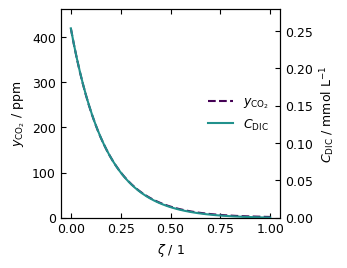

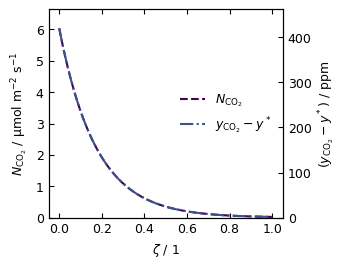


  ABSORBER KEY METRICS
  CO₂ inlet          : 420.0 ppm
  CO₂ outlet         : 1.43 ppm
  Capture efficiency : 99.66 %
  STY                : 2585.038 µmol/m³/s
  NaOH utilization   : 0.03 %
  NTU                : 5.685
  HTU                : 2.638 m
  Hatta number       : 55.40  (constant — pseudo-first-order regime)
  Enhancement factor : 55.40  (constant — large OH⁻ excess)
  K_G                : 14.371 ×10⁻³ mol m⁻² s⁻¹ atm⁻¹  (constant)
  pH                 : 14.23  (constant — NaOH barely consumed)
  Max N_CO2          : 6.036 µmol/m²/s
  Flood fraction     : 65.1 %
  Column diameter    : 29.0 cm


In [ ]:

"""
Absorber Single Column Results —
Generates characteristic plots for the NaOH packed absorber column.
"""

import os
import numpy as np
import matplotlib
import matplotlib.pyplot as plt


# ── Result directories ────────────────────────────────────────
results_dir = "model_results/"
absorber_results_dir = "model_results/standard_absorber/"
for d in [results_dir, absorber_results_dir]:
    os.makedirs(d, exist_ok=True)

# ══════════════════════════════════════════════════════════════
#  Solve
# ══════════════════════════════════════════════════════════════
print("\n" + "=" * 62)
print("  STANDARD ABSORBER — solving")
print("=" * 62)

absorber = Absorber()
absorber.solve_column()
absorber.calculate_hydraulics()
eta  = absorber.capture_efficiency()
sty  = absorber.removal_rate()
util = absorber.NaOH_utilization()
absorber.save_results(directory=absorber_results_dir, name="standard_params")

# ══════════════════════════════════════════════════════════════
#  Styling
# ══════════════════════════════════════════════════════════════
cmap   = matplotlib.colormaps["viridis"]
colors = cmap(np.linspace(0, 1, 5))
linestyles = ["-", "--", "-.", ":"]
cm = 1 / 2.54
plt.rcParams.update({"font.size": 9})

# ══════════════════════════════════════════════════════════════
#  PLOT 1 — Concentration profiles
#
#    Left:  y_CO2 in ppm (gas-phase species being absorbed)
#    Right: C_DIC in mmol/L (dissolved carbon accumulating)
#
#  These are the two quantities with real spatial variation.
#  pH, c_NaOH_free, E, Ha are all effectively constant
#  in this regime (0.03% NaOH utilization) and are reported
#  as scalar values in the metrics printout instead.
# ══════════════════════════════════════════════════════════════
fig, ax = plt.subplots(1, 1, figsize=(9*cm, 7*cm))
ax2 = ax.twinx()

plt1 = ax.plot(
    absorber.Zeta, absorber.y_CO2 * 1e6,
    label=r"$y_{\mathrm{CO}_2}$",
    color=colors[0], linestyle=linestyles[1],
)
plt2 = ax2.plot(
    absorber.Zeta, absorber.C_DIC * 1e3,
    label=r"$C_{\mathrm{DIC}}$",
    color=colors[2], linestyle=linestyles[0],
)

ax.set_xlim(-0.05, 1.05)
ax.set_ylim(0, absorber.y_CO2_in * 1e6 * 1.1)
ax2.set_ylim(0, absorber.C_DIC.max() * 1e3 * 1.1)
ax.set_xlabel(r"$\zeta$ / 1")
ax.set_ylabel(r"$y_{\mathrm{CO}_2}$ / ppm")
ax2.set_ylabel(r"$C_{\mathrm{DIC}}$ / mmol L$^{-1}$")

ax.tick_params(direction="in", axis="both", which="major",
               right=False, top=True)
ax2.tick_params(direction="in", axis="both", which="major",
                right=True, top=True)

plts = plt1 + plt2
labs = [l.get_label() for l in plts]
ax.legend(plts, labs, loc="center right", frameon=False)

plt.tight_layout()
plt.savefig(os.path.join(absorber_results_dir, "yCO2_CDIC_axial.svg"))
plt.savefig(os.path.join(absorber_results_dir, "yCO2_CDIC_axial.png"), dpi=200)
plt.show()

# ══════════════════════════════════════════════════════════════
#  PLOT 2 — Mass-transfer flux and driving force
#
#    Left:  N_CO2 (local absorption flux, µmol/m²/s)
#           — directly analogous to r_cat,surf
#    Right: (y_CO2 − y*) driving force in ppm
#           — shows WHY the flux decreases along the column,
# ══════════════════════════════════════════════════════════════
fig, ax = plt.subplots(1, 1, figsize=(9*cm, 7*cm))
ax2 = ax.twinx()

N_CO2_plot = np.maximum(absorber.N_CO2, 0.0) * 1e6
driving    = np.maximum(absorber.y_CO2 - absorber.y_star, 0.0) * 1e6

plt1 = ax.plot(
    absorber.Zeta, N_CO2_plot,
    label=r"$N_{\mathrm{CO}_2}$",
    color=colors[0], linestyle=linestyles[1],
)
plt2 = ax2.plot(
    absorber.Zeta, driving,
    label=r"$y_{\mathrm{CO}_2} - y^*$",
    color=colors[1], linestyle=linestyles[2],
)

ax.set_xlim(-0.05, 1.05)
ax.set_ylim(0, N_CO2_plot.max() * 1.1)
ax2.set_ylim(0, driving.max() * 1.1)
ax.set_xlabel(r"$\zeta$ / 1")
ax.set_ylabel(r"$N_{\mathrm{CO}_2}$ / µmol m$^{-2}$ s$^{-1}$")
ax2.set_ylabel(r"$(y_{\mathrm{CO}_2} - y^*)$ / ppm")

ax.tick_params(direction="in", axis="both", which="major",
               right=False, top=True)
ax2.tick_params(direction="in", axis="both", which="major",
                right=True, top=True)

plts = plt1 + plt2
labs = [l.get_label() for l in plts]
ax.legend(plts, labs, loc="center right", frameon=False)

plt.tight_layout()
plt.savefig(os.path.join(absorber_results_dir, "NCO2_driving_axial.svg"))
plt.savefig(os.path.join(absorber_results_dir, "NCO2_driving_axial.png"), dpi=200)
plt.show()

# ══════════════════════════════════════════════════════════════
#  Key metrics (includes constant quantities as scalars)
# ══════════════════════════════════════════════════════════════
print(f"\n{'='*62}")
print(f"  ABSORBER KEY METRICS")
print(f"{'='*62}")
print(f"  CO₂ inlet          : {absorber.y_CO2_in*1e6:.1f} ppm")
print(f"  CO₂ outlet         : {absorber.y_CO2[-1]*1e6:.2f} ppm")
print(f"  Capture efficiency : {eta:.2f} %")
print(f"  STY                : {sty*1e6:.3f} µmol/m³/s")
print(f"  NaOH utilization   : {util*100:.2f} %")
print(f"  NTU                : {absorber.NTU:.3f}")
print(f"  HTU                : {absorber.HTU:.3f} m")
print(f"  Hatta number       : {absorber.Ha.mean():.2f}"
      f"  (constant — pseudo-first-order regime)")
print(f"  Enhancement factor : {absorber.E.mean():.2f}"
      f"  (constant — large OH⁻ excess)")
print(f"  K_G                : {absorber.KG.mean()*1e3:.3f}"
      f" ×10⁻³ mol m⁻² s⁻¹ atm⁻¹  (constant)")
print(f"  pH                 : {absorber.pH.mean():.2f}"
      f"  (constant — NaOH barely consumed)")
print(f"  Max N_CO2          : {absorber.N_CO2.max()*1e6:.3f} µmol/m²/s")
print(f"  Flood fraction     : {absorber.f_flood:.1f} %")
print(f"  Column diameter    : {absorber.D_col*100:.1f} cm")
print(f"{'='*62}")

Adiabatic Column Characteristics



  ADIABATIC ABSORBER — solving
  Auto-size (gas flooding): D = 29 cm, u_G = 14.7 cm/s, flood = 65.1%, liq load = 36.3 m³/(m²·h)
  ✓ kG·a_w = 2.585 mol/(m³·s·atm) — in expected range

  Adiabatic BVP (V6.7.5)...
  Step 1: isothermal warm start...
  ✓ kG·a_w = 2.585 mol/(m³·s·atm) — in expected range

  Bracket found: [0.000234, 0.000263]  resid = [-1.965e-05, 9.166e-06]

  BVP converged:
    C_DIC(z=0, bottom) = 0.000254 mol/L
    C_DIC(z=Z, top)    = -2.72e-12 mol/L  (target = 0.0)
    The solver successfully reached the end of the integration interval.
  Warm start: C_DIC_bot = 0.000254
  Step 2: multi-start fsolve...

  Converged (norm=4.037e-21):
    C_DIC(0)=0.000254, T_L(0)=19.95°C
    C_DIC(Z)=4.04e-21, T_L(Z)=20.00°C
    The solver successfully reached the end of the integration interval.
  Saved: model_results/adiabatic_absorber/absorber_20260330-100007_adiabatic_standard_id=2273007.pkl


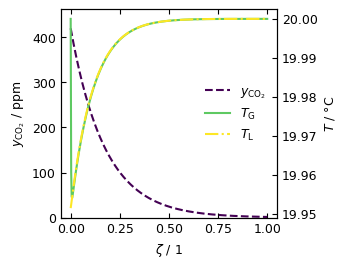

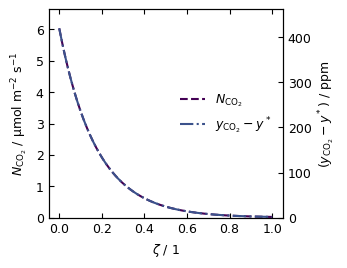


  ADIABATIC ABSORBER KEY METRICS
  CO₂ inlet          : 420.0 ppm
  CO₂ outlet         : 1.43 ppm
  Capture efficiency : 99.66 %
  STY                : 2585.039 µmol/m³/s
  NaOH utilization   : 0.03 %
  NTU                : 5.685
  HTU                : 2.638 m
  T_G bot / top      : 20.00 / 20.00 °C
  T_L bot / top      : 19.95 / 20.00 °C
  ΔT_G               : 0.00 K
  ΔT_L               : -0.05 K
  Hatta number       : 55.29 – 55.40
  Enhancement factor : 55.29 – 55.41
  K_G range          : 14.369 – 14.371 ×10⁻³
  pH bot / top       : 14.23 / 14.23
  Max N_CO2          : 6.035 µmol/m²/s
  Q_rxn              : 18.40 W
  Q_evap             : 152.71 W
  Q_GL               : 0.02 W
  Flood fraction     : 65.1 %
  Column diameter    : 29.0 cm


In [ ]:

"""
Adiabatic Absorber Single Column Results
Generates characteristic plots for the adiabatic NaOH packed absorber.

In the adiabatic case, T_G and T_L vary along the column, which causes
Ha, E, K_G, and pH to also vary — giving richer profiles than isothermal.
"""

import os
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter

# ── Result directories ────────────────────────────────────────
results_dir = "model_results/"
adiabatic_results_dir = "model_results/adiabatic_absorber/"
for d in [results_dir, adiabatic_results_dir]:
    os.makedirs(d, exist_ok=True)

# ══════════════════════════════════════════════════════════════
#  Solve
# ══════════════════════════════════════════════════════════════
print("\n" + "=" * 62)
print("  ADIABATIC ABSORBER — solving")
print("=" * 62)

absorber = AdiabaticAbsorber()
absorber.solve_column()
absorber.calculate_hydraulics()
eta  = absorber.capture_efficiency()
sty  = absorber.removal_rate()
util = absorber.NaOH_utilization()
absorber.save_results(directory=adiabatic_results_dir, name="adiabatic_standard")

# ══════════════════════════════════════════════════════════════
#  Styling
# ══════════════════════════════════════════════════════════════
cmap   = matplotlib.colormaps["viridis"]
colors = cmap(np.linspace(0, 1, 5))
linestyles = ["-", "--", "-.", ":"]
cm = 1 / 2.54
plt.rcParams.update({"font.size": 9})

# ══════════════════════════════════════════════════════════════
#  PLOT 1 — Concentration profiles + temperature
#
#  In the adiabatic case, temperature varies along the column,
#  so it is meaningful to plot — unlike the isothermal case.
#
#  Left axis:  y_CO2 [ppm]  (gas-phase CO₂ being absorbed)
#  Right axis: T_G and T_L  [°C]  (gas and liquid temperatures)
#
#  C_DIC is not co-plotted here because its scale (mmol/L)
#  would be crushed by y_CO2 (ppm). It appears in Plot 2.
# ══════════════════════════════════════════════════════════════
fig, ax = plt.subplots(1, 1, figsize=(9*cm, 7*cm))
ax2 = ax.twinx()

plt1 = ax.plot(
    absorber.Zeta, absorber.y_CO2 * 1e6,
    label=r"$y_{\mathrm{CO}_2}$",
    color=colors[0], linestyle=linestyles[1],
)
plt2 = ax2.plot(
    absorber.Zeta, absorber.T_G - 273.15,
    label=r"$T_{\mathrm{G}}$",
    color=colors[3], linestyle=linestyles[0],
)
plt3 = ax2.plot(
    absorber.Zeta, absorber.T_L - 273.15,
    label=r"$T_{\mathrm{L}}$",
    color=colors[4], linestyle=linestyles[2],
)

ax.set_xlim(-0.05, 1.05)
ax.set_ylim(0, absorber.y_CO2_in * 1e6 * 1.1)
ax.set_xlabel(r"$\zeta$ / 1")
ax.set_ylabel(r"$y_{\mathrm{CO}_2}$ / ppm")
ax2.set_ylabel(r"$T$ / °C")

ax.tick_params(direction="in", axis="both", which="major",
               right=False, top=True)
ax2.tick_params(direction="in", axis="both", which="major",
                right=True, top=True)

plts = plt1 + plt2 + plt3
labs = [l.get_label() for l in plts]
ax.legend(plts, labs, loc="center right", frameon=False)

plt.tight_layout()
plt.savefig(os.path.join(adiabatic_results_dir, "yCO2_T_axial.svg"))
plt.savefig(os.path.join(adiabatic_results_dir, "yCO2_T_axial.png"), dpi=200)
plt.show()

# ══════════════════════════════════════════════════════════════
#  PLOT 2 — Mass-transfer flux and driving force
#
#  Left axis:  N_CO2 [µmol/m²/s]  (local absorption flux)
#  Right axis: (y_CO2 − y*) [ppm] (driving force)
# ══════════════════════════════════════════════════════════════
fig, ax = plt.subplots(1, 1, figsize=(9*cm, 7*cm))
ax2 = ax.twinx()

N_CO2_plot = np.maximum(absorber.N_CO2, 0.0) * 1e6
driving    = np.maximum(absorber.y_CO2 - absorber.y_star, 0.0) * 1e6

plt1 = ax.plot(
    absorber.Zeta, N_CO2_plot,
    label=r"$N_{\mathrm{CO}_2}$",
    color=colors[0], linestyle=linestyles[1],
)
plt2 = ax2.plot(
    absorber.Zeta, driving,
    label=r"$y_{\mathrm{CO}_2} - y^*$",
    color=colors[1], linestyle=linestyles[2],
)

ax.set_xlim(-0.05, 1.05)
ax.set_ylim(0, N_CO2_plot.max() * 1.1)
ax2.set_ylim(0, driving.max() * 1.1)
ax.set_xlabel(r"$\zeta$ / 1")
ax.set_ylabel(r"$N_{\mathrm{CO}_2}$ / µmol m$^{-2}$ s$^{-1}$")
ax2.set_ylabel(r"$(y_{\mathrm{CO}_2} - y^*)$ / ppm")

ax.tick_params(direction="in", axis="both", which="major",
               right=False, top=True)
ax2.tick_params(direction="in", axis="both", which="major",
                right=True, top=True)

plts = plt1 + plt2
labs = [l.get_label() for l in plts]
ax.legend(plts, labs, loc="center right", frameon=False)

plt.tight_layout()
plt.savefig(os.path.join(adiabatic_results_dir, "NCO2_driving_axial.svg"))
plt.savefig(os.path.join(adiabatic_results_dir, "NCO2_driving_axial.png"), dpi=200)
plt.show()

# ══════════════════════════════════════════════════════════════
#  Key metrics
# ══════════════════════════════════════════════════════════════
print(f"\n{'='*62}")
print(f"  ADIABATIC ABSORBER KEY METRICS")
print(f"{'='*62}")
print(f"  CO₂ inlet          : {absorber.y_CO2_in*1e6:.1f} ppm")
print(f"  CO₂ outlet         : {absorber.y_CO2[-1]*1e6:.2f} ppm")
print(f"  Capture efficiency : {eta:.2f} %")
print(f"  STY                : {sty*1e6:.3f} µmol/m³/s")
print(f"  NaOH utilization   : {util*100:.2f} %")
print(f"  NTU                : {absorber.NTU:.3f}")
print(f"  HTU                : {absorber.HTU:.3f} m")
print(f"  T_G bot / top      : {absorber.T_G[0]-273.15:.2f} /"
      f" {absorber.T_G[-1]-273.15:.2f} °C")
print(f"  T_L bot / top      : {absorber.T_L[0]-273.15:.2f} /"
      f" {absorber.T_L[-1]-273.15:.2f} °C")
print(f"  ΔT_G               : {absorber.T_G[-1]-absorber.T_G[0]:.2f} K")
print(f"  ΔT_L               : {absorber.T_L[0]-absorber.T_L[-1]:.2f} K")
print(f"  Hatta number       : {absorber.Ha.min():.2f} – {absorber.Ha.max():.2f}")
print(f"  Enhancement factor : {absorber.E.min():.2f} – {absorber.E.max():.2f}")
print(f"  K_G range          : {absorber.KG.min()*1e3:.3f} –"
      f" {absorber.KG.max()*1e3:.3f} ×10⁻³")
print(f"  pH bot / top       : {absorber.pH[0]:.2f} / {absorber.pH[-1]:.2f}")
print(f"  Max N_CO2          : {absorber.N_CO2.max()*1e6:.3f} µmol/m²/s")
print(f"  Q_rxn              : {absorber.Q_rxn_total:.2f} W")
print(f"  Q_evap             : {absorber.Q_evap_total:.2f} W")
print(f"  Q_GL               : {absorber.Q_GL_total:.2f} W")
print(f"  Flood fraction     : {absorber.f_flood:.1f} %")
print(f"  Column diameter    : {absorber.D_col*100:.1f} cm")
print(f"{'='*62}")

Sensitivity Analysis - Gas Flow rate


  STANDARD ABSORBER — Solving
  Auto-size (gas flooding): D = 29 cm, u_G = 14.7 cm/s, flood = 65.1%, liq load = 36.3 m³/(m²·h)
  ✓ kG·a_w = 2.585 mol/(m³·s·atm) — in expected range

  Bracket found: [0.000234, 0.000263]  resid = [-1.965e-05, 9.166e-06]

  BVP converged:
    C_DIC(z=0, bottom) = 0.000254 mol/L
    C_DIC(z=Z, top)    = -2.72e-12 mol/L  (target = 0.0)
    The solver successfully reached the end of the integration interval.
  Saved: absorber_results/standard_absorber/absorber_20260330-100108_standard_params_id=9450946.pkl


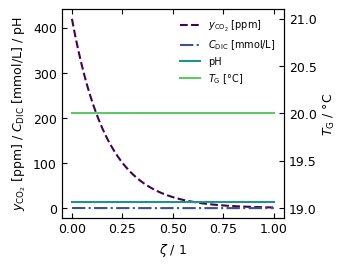

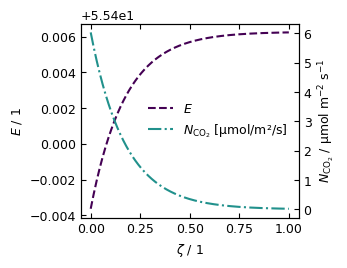


  Standard absorber results:
    η (capture efficiency)  = 99.66 %
    STY (removal rate)      = 2585.038 µmol/m³/s
    NaOH utilization        = 0.03 %
    CO₂ in                  = 420.0 ppm
    CO₂ out                 = 1.43 ppm
    Max Ha                  = 55.40
    Max E                   = 55.41

  SENSITIVITY: Gas volumetric flow rate (G_vol)

  Case 0: G_vol = 5.0 m³/h
  Auto-size (gas flooding): D = 1957 cm, u_G = 0.0 cm/s, flood = 70.0%, liq load = 0.0 m³/(m²·h)
  ⚠ kG·a_w = 0.000 mol/(m³·s·atm) — very low

  Bracket found: [0.000033, 0.000037]  resid = [-3.762e-06, 2.429e-07]

  BVP converged:
    C_DIC(z=0, bottom) = 0.000036 mol/L
    C_DIC(z=Z, top)    = -1.42e-14 mol/L  (target = 0.0)
    The solver successfully reached the end of the integration interval.
  Saved: absorber_results/sensitivity/gas_flow_variation/absorber_20260330-100209_var_G_vol_0_G_vol=5.0_id=5824840.pkl

  Case 1: G_vol = 10.0 m³/h
  Auto-size (gas flooding): D = 155 cm, u_G = 0.1 cm/s, flood = 69.7

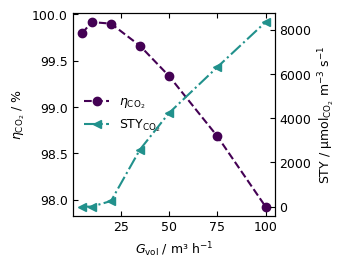


  Gas flow sensitivity complete.
  Results saved to: absorber_results/sensitivity/gas_flow_variation/


In [ ]:

"""
Sensitivity Analysis for 1D Counter-Current NaOH Packed Absorber (DAC of CO2)

"""

import os
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

# =============================================================================
# Directory setup
# =============================================================================
results_dir = 'absorber_results/'
if not os.path.exists(results_dir):
    os.makedirs(results_dir)

standard_absorber_dir = 'absorber_results/standard_absorber/'
if not os.path.exists(standard_absorber_dir):
    os.makedirs(standard_absorber_dir)

sensitivity_dir = 'absorber_results/sensitivity/'
if not os.path.exists(sensitivity_dir):
    os.makedirs(sensitivity_dir)

gas_flow_variation_dir = 'absorber_results/sensitivity/gas_flow_variation/'
if not os.path.exists(gas_flow_variation_dir):
    os.makedirs(gas_flow_variation_dir)

# =============================================================================
# Plotting style
# =============================================================================
cm = 1 / 2.54
plt.rcParams.update({'font.size': 9})

# =============================================================================
# STANDARD CASE — Isothermal Absorber
# =============================================================================
print("\n" + "=" * 62)
print("  STANDARD ABSORBER — Solving")
print("=" * 62)

standard_absorber = Absorber()
standard_absorber.solve_column()
standard_absorber.calculate_hydraulics()
eta = standard_absorber.capture_efficiency()
sty = standard_absorber.removal_rate()
util = standard_absorber.NaOH_utilization()
standard_absorber.save_results(directory=standard_absorber_dir, name="standard_params")

# ── Graph 1: Species profiles + temperature along column ──
# Here: y_CO2, C_DIC, pH along normalised column height + T_G on twin axis

cmap = matplotlib.colormaps["viridis"]
colors = cmap(np.linspace(0, 1, 5))
linestyles = ["-", "--", "-.", ":", "-"]

fig, ax = plt.subplots(1, 1, figsize=(9 * cm, 7 * cm))
ax2 = ax.twinx()

plt1 = ax.plot(
    standard_absorber.Zeta,
    standard_absorber.y_CO2 * 1e6,
    label=r"$y_{\mathrm{CO}_2}$ [ppm]",
    color=colors[0],
    linestyle=linestyles[1],
)
plt2 = ax.plot(
    standard_absorber.Zeta,
    standard_absorber.C_DIC * 1e3,          # mol/L → mmol/L for readability
    label=r"$C_{\mathrm{DIC}}$ [mmol/L]",
    color=colors[1],
    linestyle=linestyles[2],
)
plt3 = ax.plot(
    standard_absorber.Zeta,
    standard_absorber.pH,
    label="pH",
    color=colors[2],
    linestyle=linestyles[0],
)
plt4 = ax2.plot(
    standard_absorber.Zeta,
    standard_absorber.T_G - 273.15,
    label=r"$T_{\mathrm{G}}$ [°C]",
    color=colors[3],
    linestyle=linestyles[0],
)

ax.set_xlim(-0.05, 1.05)
ax.set_xlabel(r"$\zeta$ / 1")
ax.set_ylabel(r"$y_{\mathrm{CO}_2}$ [ppm] / $C_{\mathrm{DIC}}$ [mmol/L] / pH")
ax2.set_ylabel(r"$T_{\mathrm{G}}$ / °C")
ax.tick_params(direction="in", axis="both", which="major", right=False, top=True)
ax2.tick_params(direction="in", axis="both", which="major", right=True, top=True)

plts = plt1 + plt2 + plt3 + plt4
labs = [l.get_label() for l in plts]
ax.legend(plts, labs, loc="best", frameon=False, fontsize=7)
plt.tight_layout()
plt.savefig(os.path.join(standard_absorber_dir, "y_CO2_C_DIC_pH_T_axial.svg"))
plt.savefig(os.path.join(standard_absorber_dir, "y_CO2_C_DIC_pH_T_axial.png"), dpi=150)
plt.show()

# ── Graph 2: Enhancement factor + CO2 flux along column ──
# Here: Enhancement E + local CO2 flux N_CO2

cmap = matplotlib.colormaps["viridis"]
colors = cmap(np.linspace(0, 1, 3))

fig, ax = plt.subplots(1, 1, figsize=(9 * cm, 7 * cm))
ax2 = ax.twinx()

plt1 = ax.plot(
    standard_absorber.Zeta,
    standard_absorber.E,
    label=r"$E$",
    color=colors[0],
    linestyle=linestyles[1],
)
plt2 = ax2.plot(
    standard_absorber.Zeta,
    standard_absorber.N_CO2 * 1e6,
    label=r"$N_{\mathrm{CO}_2}$ [µmol/m²/s]",
    color=colors[1],
    linestyle=linestyles[2],
)

ax.set_xlim(-0.05, 1.05)
ax.set_xlabel(r"$\zeta$ / 1")
ax.set_ylabel(r"$E$ / 1")
ax2.set_ylabel(r"$N_{\mathrm{CO}_2}$ / µmol m$^{-2}$ s$^{-1}$")
ax.tick_params(direction="in", axis="both", which="major", right=False, top=True)
ax2.tick_params(direction="in", axis="both", which="major", right=True, top=True)

plts = plt1 + plt2
labs = [l.get_label() for l in plts]
ax.legend(plts, labs, loc="right", frameon=False)
plt.tight_layout()
plt.savefig(os.path.join(standard_absorber_dir, "E_N_CO2_axial.svg"))
plt.savefig(os.path.join(standard_absorber_dir, "E_N_CO2_axial.png"), dpi=150)
plt.show()

# Print key performance metrics
print(f"\n  Standard absorber results:")
print(f"    η (capture efficiency)  = {eta:.2f} %")
print(f"    STY (removal rate)      = {sty * 1e6:.3f} µmol/m³/s")
print(f"    NaOH utilization        = {util * 100:.2f} %")
print(f"    CO₂ in                  = {standard_absorber.y_CO2_in * 1e6:.1f} ppm")
print(f"    CO₂ out                 = {standard_absorber.y_CO2[-1] * 1e6:.2f} ppm")
print(f"    Max Ha                  = {standard_absorber.Ha.max():.2f}")
print(f"    Max E                   = {standard_absorber.E.max():.2f}")

# =============================================================================
# SENSITIVITY 1: Variation of gas volumetric flow rate (G_vol)
# =============================================================================
print("\n" + "=" * 62)
print("  SENSITIVITY: Gas volumetric flow rate (G_vol)")
print("=" * 62)

G_vol_values = [5.0, 10.0, 20.0, 35.0, 50.0, 75.0, 100.0]  # m³/h

absorber_var_G_vol = {}
n_sensitivity = len(G_vol_values)

for w in range(n_sensitivity):
    print(f"\n  Case {w}: G_vol = {G_vol_values[w]} m³/h")
    absorber_var_G_vol[w] = Absorber(G_vol=G_vol_values[w])
    absorber_var_G_vol[w].solve_column()
    absorber_var_G_vol[w].calculate_hydraulics()
    _ = absorber_var_G_vol[w].capture_efficiency()
    _ = absorber_var_G_vol[w].removal_rate()
    _ = absorber_var_G_vol[w].NaOH_utilization()
    absorber_var_G_vol[w].save_results(
        directory=gas_flow_variation_dir,
        name=f"var_G_vol_{w}_G_vol={G_vol_values[w]}",
    )

# Plot: η and STY vs G_vol
cmap = matplotlib.colormaps["viridis"]
colors = cmap(np.linspace(0, 1, 3))

fig, ax = plt.subplots(1, 1, figsize=(9 * cm, 7 * cm))
ax2 = ax.twinx()

plt1 = ax.plot(
    G_vol_values,
    [absorber_var_G_vol[w].eta for w in range(n_sensitivity)],
    "o",
    label=r"$\eta_{\mathrm{CO}_2}$",
    color=colors[0],
    linestyle="--",
)
plt2 = ax2.plot(
    G_vol_values,
    [absorber_var_G_vol[w].STY * 1e6 for w in range(n_sensitivity)],
    "<",
    label=r"STY$_{\mathrm{CO}_2}$",
    color=colors[1],
    linestyle="-.",
)

ax.set_xlabel(r"$G_{\mathrm{vol}}$ / m³ h$^{-1}$")
ax.set_ylabel(r"$\eta_{\mathrm{CO}_2}$ / %")
ax2.set_ylabel(r"STY / µmol$_{\mathrm{CO}_2}$ m$^{-3}$ s$^{-1}$")
ax.tick_params(direction="in", axis="both", which="both", right=False, top=True)
ax2.tick_params(direction="in", axis="both", which="both", right=True, top=True)

plts = plt1 + plt2
labs = [l.get_label() for l in plts]
ax.legend(plts, labs, loc="center left", frameon=False)
plt.tight_layout()
plt.savefig(os.path.join(gas_flow_variation_dir, "var_G_vol_eta_STY.svg"))
plt.savefig(os.path.join(gas_flow_variation_dir, "var_G_vol_eta_STY.png"), dpi=150)
plt.show()

print("\n  Gas flow sensitivity complete.")
print("  Results saved to:", gas_flow_variation_dir)

Senstivity Analysis - Variation of Liquid Flow rate


Sensitivity case: 0
  variation of: L_vol_flow
  value = 1.0 L/min
  Auto-size (min diameter / max velocity): D = 15 cm, u_G = 55.0 cm/s, flood = 19.6%, liq load = 3.4 m³/(m²·h)
  ⚠ Low flood fraction (19.6%). Gas-sized D = 9 cm would give better gas-side MT.
  ✓ kG·a_w = 3.474 mol/(m³·s·atm) — in expected range

  Bracket found: [0.007617, 0.008555]  resid = [-8.243e-04, 1.139e-04]

  BVP converged:
    C_DIC(z=0, bottom) = 0.008441 mol/L
    C_DIC(z=Z, top)    = -6.88e-16 mol/L  (target = 0.0)
    The solver successfully reached the end of the integration interval.
  η = 83.02 %
  STY = 30085.327 µmol/m³/s
  NaOH util = 0.84 %
  Saved: absorber_results/sensitivity/liquid_flow_variation/absorber_20260330-100909_var_L_vol_flow_0_L=1.0_id=1384145.pkl

Sensitivity case: 1
  variation of: L_vol_flow
  value = 5.0 L/min
  Auto-size (min diameter / max velocity): D = 15 cm, u_G = 55.0 cm/s, flood = 28.6%, liq load = 17.0 m³/(m²·h)
  ⚠ Low flood fraction (28.6%). Gas-sized D = 10 cm would g

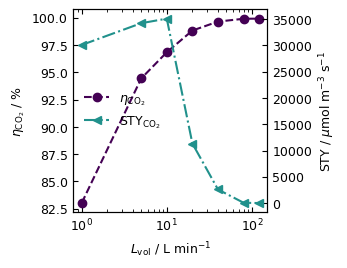

Plot 1 saved.


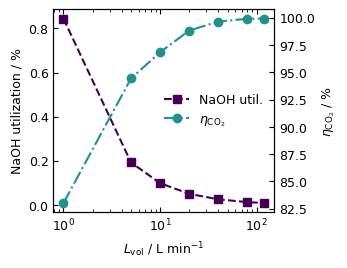

Plot 2 saved.

  SENSITIVITY SUMMARY — Liquid Flow Rate Variation
   L_vol [L/min]     η [%]   STY [µmol/m³/s]   NaOH util [%]
  --------------  --------  ----------------  --------------
             1.0     83.02         30085.327            0.84
             5.0     94.44         34224.608            0.19
            10.0     96.85         35096.820            0.10
            20.0     98.84         11333.042            0.05
            40.0     99.66          2585.038            0.03
            80.0     99.92            57.935            0.01
           120.0     99.93             1.499            0.01


In [ ]:
# =============================================================================
# SENSITIVITY ANALYSIS — Variation of Liquid Flow Rate (L_vol_flow)
# =============================================================================

import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import warnings
import sys


# Suppress warnings during sensitivity runs
warnings.filterwarnings('ignore')

# ---- Results directory ----
import os
sensitivity_results_dir = 'absorber_results/sensitivity/'
liquid_flow_variation_dir = sensitivity_results_dir + 'liquid_flow_variation/'
if not os.path.exists(liquid_flow_variation_dir):
    os.makedirs(liquid_flow_variation_dir)

# ---- Parameter values to sweep ----
L_vol_flow_values = [1.0, 5.0, 10.0, 20.0, 40.0, 80.0, 120.0]

# ---- Run simulations ----
absorber_var_L = {}
n_sensitivity = len(L_vol_flow_values)

for w in range(n_sensitivity):
    print(f"\nSensitivity case: {w}")
    print(f"  variation of: L_vol_flow")
    print(f"  value = {L_vol_flow_values[w]} L/min")

    absorber_var_L[w] = Absorber(L_vol_flow=L_vol_flow_values[w])
    absorber_var_L[w].solve_column()
    absorber_var_L[w].calculate_hydraulics()

    # Compute performance metrics
    eta = absorber_var_L[w].capture_efficiency()
    sty = absorber_var_L[w].removal_rate()
    util = absorber_var_L[w].NaOH_utilization()

    print(f"  η = {eta:.2f} %")
    print(f"  STY = {sty * 1e6:.3f} µmol/m³/s")
    print(f"  NaOH util = {util * 100:.2f} %")

    # Save results
    absorber_var_L[w].save_results(
        directory=liquid_flow_variation_dir,
        name=f"var_L_vol_flow_{w}_L={L_vol_flow_values[w]}"
    )

# ---- Collect results ----
eta_values = [absorber_var_L[w].capture_efficiency() for w in range(n_sensitivity)]
sty_values = [absorber_var_L[w].removal_rate() * 1e6 for w in range(n_sensitivity)]
util_values = [absorber_var_L[w].NaOH_utilization() * 100 for w in range(n_sensitivity)]

# ---- Plot 1: Capture Efficiency & STY vs L_vol_flow ----
cmap = matplotlib.colormaps["viridis"]
colors = cmap(np.linspace(0, 1, 3))
linestyles = ["-", "--", "-.", ":", "-", "--", "-.", ":"]
cm = 1 / 2.54

plt.rcParams.update({'font.size': 9})

fig, ax = plt.subplots(1, 1, figsize=(9 * cm, 7 * cm))
ax2 = ax.twinx()

plt1 = ax.plot(
    L_vol_flow_values,
    eta_values,
    'o', label=r'$\eta_{\mathrm{CO}_2}$',
    color=colors[0], linestyle=linestyles[1]
)
plt2 = ax2.plot(
    L_vol_flow_values,
    sty_values,
    '<', label=r'STY$_{\mathrm{CO}_2}$',
    color=colors[1], linestyle=linestyles[2]
)

ax.set_xlabel(r'$L_{\mathrm{vol}}$ / L min$^{-1}$')
ax.set_ylabel(r'$\eta_{\mathrm{CO}_2}$ / %')
ax2.set_ylabel(r'STY / $\mu$mol m$^{-3}$ s$^{-1}$')
ax.set_xscale('log')

ax.tick_params(direction="in", axis='both', which='both', right=False, top=True)
ax2.tick_params(direction="in", axis='both', which='both', right=True, top=True)

plts = plt1 + plt2
labs = [l.get_label() for l in plts]
ax.legend(plts, labs, loc="center left", frameon=False)

plt.tight_layout()
plt.savefig(liquid_flow_variation_dir + "var_L_vol_flow_eta_STY.svg")
plt.savefig(liquid_flow_variation_dir + "var_L_vol_flow_eta_STY.png", dpi=150)
plt.show()
print("Plot 1 saved.")

# ---- Plot 2: NaOH Utilization & Capture Efficiency vs L_vol_flow ----
fig, ax = plt.subplots(1, 1, figsize=(9 * cm, 7 * cm))
ax2 = ax.twinx()

plt1 = ax.plot(
    L_vol_flow_values,
    util_values,
    's', label=r'NaOH util.',
    color=colors[0], linestyle=linestyles[1]
)
plt2 = ax2.plot(
    L_vol_flow_values,
    eta_values,
    'o', label=r'$\eta_{\mathrm{CO}_2}$',
    color=colors[1], linestyle=linestyles[2]
)

ax.set_xlabel(r'$L_{\mathrm{vol}}$ / L min$^{-1}$')
ax.set_ylabel('NaOH utilization / %')
ax2.set_ylabel(r'$\eta_{\mathrm{CO}_2}$ / %')
ax.set_xscale('log')

ax.tick_params(direction="in", axis='both', which='both', right=False, top=True)
ax2.tick_params(direction="in", axis='both', which='both', right=True, top=True)

plts = plt1 + plt2
labs = [l.get_label() for l in plts]
ax.legend(plts, labs, loc="center right", frameon=False)

plt.tight_layout()
plt.savefig(liquid_flow_variation_dir + "var_L_vol_flow_util_eta.svg")
plt.savefig(liquid_flow_variation_dir + "var_L_vol_flow_util_eta.png", dpi=150)
plt.show()
print("Plot 2 saved.")

# ---- Print summary table ----
print(f"\n{'=' * 70}")
print(f"  SENSITIVITY SUMMARY — Liquid Flow Rate Variation")
print(f"{'=' * 70}")
print(f"  {'L_vol [L/min]':>14s}  {'η [%]':>8s}  {'STY [µmol/m³/s]':>16s}  {'NaOH util [%]':>14s}")
print(f"  {'-'*14}  {'-'*8}  {'-'*16}  {'-'*14}")
for w in range(n_sensitivity):
    print(f"  {L_vol_flow_values[w]:>14.1f}  {eta_values[w]:>8.2f}  {sty_values[w]:>16.3f}  {util_values[w]:>14.2f}")
print(f"{'=' * 70}")

Senstivity Analysis - Variation of NaOH concentration


Sensitivity case: 0
  variation of: c_NaOH_in
  value = 0.1 mol/L
  Auto-size (gas flooding): D = 29 cm, u_G = 14.7 cm/s, flood = 65.1%, liq load = 36.3 m³/(m²·h)
  ✓ kG·a_w = 2.585 mol/(m³·s·atm) — in expected range

  Bracket found: [0.000234, 0.000256]  resid = [-1.857e-05, 3.678e-06]

  BVP converged:
    C_DIC(z=0, bottom) = 0.000252 mol/L
    C_DIC(z=Z, top)    = 2.38e-11 mol/L  (target = 0.0)
    The solver successfully reached the end of the integration interval.
  η = 99.11 %
  STY = 2570.799 µmol/m³/s
  NaOH util = 0.50 %
  Saved: absorber_results/sensitivity/NaOH_concentration_variation/absorber_20260330-101612_var_c_NaOH_0_c=0.1_auto_id=3823488.pkl

Sensitivity case: 1
  variation of: c_NaOH_in
  value = 0.5 mol/L
  Auto-size (gas flooding): D = 29 cm, u_G = 14.7 cm/s, flood = 65.1%, liq load = 36.3 m³/(m²·h)
  ✓ kG·a_w = 2.585 mol/(m³·s·atm) — in expected range

  Bracket found: [0.000253, 0.000281]  resid = [-1.545e-07, 2.774e-05]

  BVP converged:
    C_DIC(z=0, bottom)

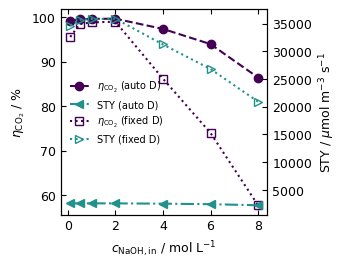

Plot 1 saved.


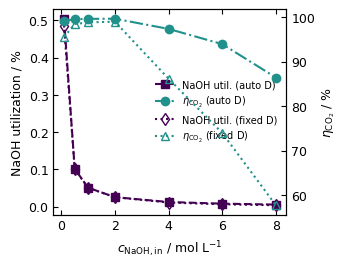

Plot 2 saved.

  SENSITIVITY SUMMARY — NaOH Concentration Variation (Auto-Sized)
  c_NaOH [mol/L]     η [%]   STY [µmol/m³/s]   NaOH util [%]
  --------------  --------  ----------------  --------------
             0.1     99.11          2570.799            0.50
             0.5     99.57          2582.654            0.10
             1.0     99.64          2584.392            0.05
             2.0     99.66          2585.038            0.03
             4.0     97.37          2525.682            0.01
             6.0     93.95          2437.015            0.01
             8.0     86.45          2242.262            0.01

  SENSITIVITY SUMMARY — NaOH Concentration Variation (Fixed D = 15 cm)
  c_NaOH [mol/L]     η [%]   STY [µmol/m³/s]   NaOH util [%]
  --------------  --------  ----------------  --------------
             0.1     95.57         34632.303            0.49
             0.5     98.45         35676.757            0.10
             1.0     98.85         35821.431          

In [ ]:
# =============================================================================
# SENSITIVITY ANALYSIS — Variation of NaOH Concentration (c_NaOH_in)
# =============================================================================

import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import warnings
import sys

# Suppress warnings during sensitivity runs
warnings.filterwarnings('ignore')

# ---- Results directory ----
import os
sensitivity_results_dir = 'absorber_results/sensitivity/'
NaOH_concentration_variation_dir = sensitivity_results_dir + 'NaOH_concentration_variation/'
if not os.path.exists(NaOH_concentration_variation_dir):
    os.makedirs(NaOH_concentration_variation_dir)

# ---- Parameter values to sweep ----
c_NaOH_values = [0.1, 0.5, 1.0, 2.0, 4.0, 6.0, 8.0]

# ---- Fixed diameter for fair comparison ----
# All cases use the same column geometry so STY reflects
# only the effect of NaOH concentration, not auto-sizing artifacts.
D_COL_FIXED = 0.15  # 15 cm — matches baseline auto-sized D

# ---- Run simulations (auto-sized) ----
absorber_var_NaOH_auto = {}
n_sensitivity = len(c_NaOH_values)

for w in range(n_sensitivity):
    print(f"\nSensitivity case: {w}")
    print(f"  variation of: c_NaOH_in")
    print(f"  value = {c_NaOH_values[w]} mol/L")

    absorber_var_NaOH_auto[w] = Absorber(c_NaOH_in=c_NaOH_values[w])
    absorber_var_NaOH_auto[w].solve_column()
    absorber_var_NaOH_auto[w].calculate_hydraulics()

    # Compute performance metrics
    eta = absorber_var_NaOH_auto[w].capture_efficiency()
    sty = absorber_var_NaOH_auto[w].removal_rate()
    util = absorber_var_NaOH_auto[w].NaOH_utilization()

    print(f"  η = {eta:.2f} %")
    print(f"  STY = {sty * 1e6:.3f} µmol/m³/s")
    print(f"  NaOH util = {util * 100:.2f} %")

    # Save results
    absorber_var_NaOH_auto[w].save_results(
        directory=NaOH_concentration_variation_dir,
        name=f"var_c_NaOH_{w}_c={c_NaOH_values[w]}_auto"
    )

# ---- Run simulations (fixed diameter) ----
absorber_var_NaOH_fixed = {}

print(f"\n{'=' * 70}")
print(f"  FIXED-DIAMETER RUNS  (D_col = {D_COL_FIXED*100:.0f} cm)")
print(f"{'=' * 70}")

for w in range(n_sensitivity):
    print(f"\n[Fixed] Case {w}: c_NaOH_in = {c_NaOH_values[w]} mol/L")
    try:
        absorber_var_NaOH_fixed[w] = Absorber(
            c_NaOH_in=c_NaOH_values[w],
            D_col=D_COL_FIXED
        )
        absorber_var_NaOH_fixed[w].solve_column()
        absorber_var_NaOH_fixed[w].calculate_hydraulics()

        eta = absorber_var_NaOH_fixed[w].capture_efficiency()
        sty = absorber_var_NaOH_fixed[w].removal_rate()
        util = absorber_var_NaOH_fixed[w].NaOH_utilization()

        print(f"  η = {eta:.2f} %")
        print(f"  STY = {sty * 1e6:.3f} µmol/m³/s")
        print(f"  NaOH util = {util * 100:.2f} %")
        print(f"  flood = {absorber_var_NaOH_fixed[w].f_flood:.1f} %")

        if absorber_var_NaOH_fixed[w].f_flood > 80:
            print(f"  ⚠ Flood = {absorber_var_NaOH_fixed[w].f_flood:.1f}% — column may flood!")

        absorber_var_NaOH_fixed[w].save_results(
            directory=NaOH_concentration_variation_dir,
            name=f"var_c_NaOH_{w}_c={c_NaOH_values[w]}_fixedD"
        )
    except Exception as e:
        print(f"  ✗ Simulation failed: {e}")

# ---- Collect results (auto-sized) ----
eta_values_auto = [absorber_var_NaOH_auto[w].capture_efficiency() for w in range(n_sensitivity)]
sty_values_auto = [absorber_var_NaOH_auto[w].removal_rate() * 1e6 for w in range(n_sensitivity)]
util_values_auto = [absorber_var_NaOH_auto[w].NaOH_utilization() * 100 for w in range(n_sensitivity)]

# ---- Collect results (fixed diameter) ----
eta_values_fixed = []
sty_values_fixed = []
util_values_fixed = []
c_NaOH_fixed_ok = []
for w in range(n_sensitivity):
    if w in absorber_var_NaOH_fixed:
        eta_values_fixed.append(absorber_var_NaOH_fixed[w].capture_efficiency())
        sty_values_fixed.append(absorber_var_NaOH_fixed[w].removal_rate() * 1e6)
        util_values_fixed.append(absorber_var_NaOH_fixed[w].NaOH_utilization() * 100)
        c_NaOH_fixed_ok.append(c_NaOH_values[w])

# ---- Plot setup ----
cmap = matplotlib.colormaps["viridis"]
colors = cmap(np.linspace(0, 1, 3))
linestyles = ["-", "--", "-.", ":", "-", "--", "-.", ":"]
cm = 1 / 2.54
plt.rcParams.update({'font.size': 9})

# ---- Plot 1: Capture Efficiency & STY vs c_NaOH ----
fig, ax = plt.subplots(1, 1, figsize=(9 * cm, 7 * cm))
ax2 = ax.twinx()

plt1 = ax.plot(
    c_NaOH_values, eta_values_auto,
    'o', label=r'$\eta_{\mathrm{CO}_2}$ (auto D)',
    color=colors[0], linestyle=linestyles[1]
)
plt2 = ax2.plot(
    c_NaOH_values, sty_values_auto,
    '<', label=r'STY (auto D)',
    color=colors[1], linestyle=linestyles[2]
)

if len(c_NaOH_fixed_ok) > 0:
    plt3 = ax.plot(
        c_NaOH_fixed_ok, eta_values_fixed,
        's', label=r'$\eta_{\mathrm{CO}_2}$ (fixed D)',
        color=colors[0], linestyle=linestyles[3], mfc='none'
    )
    plt4 = ax2.plot(
        c_NaOH_fixed_ok, sty_values_fixed,
        '>', label=r'STY (fixed D)',
        color=colors[1], linestyle=linestyles[3], mfc='none'
    )
    plts = plt1 + plt2 + plt3 + plt4
else:
    plts = plt1 + plt2

ax.set_xlabel(r'$c_{\mathrm{NaOH,in}}$ / mol L$^{-1}$')
ax.set_ylabel(r'$\eta_{\mathrm{CO}_2}$ / %')
ax2.set_ylabel(r'STY / $\mu$mol m$^{-3}$ s$^{-1}$')

ax.tick_params(direction="in", axis='both', which='both', right=False, top=True)
ax2.tick_params(direction="in", axis='both', which='both', right=True, top=True)

labs = [l.get_label() for l in plts]
ax.legend(plts, labs, loc="center left", frameon=False, fontsize=7)

plt.tight_layout()
plt.savefig(NaOH_concentration_variation_dir + "var_c_NaOH_eta_STY.svg")
plt.savefig(NaOH_concentration_variation_dir + "var_c_NaOH_eta_STY.png", dpi=150)
plt.show()
print("Plot 1 saved.")

# ---- Plot 2: NaOH Utilization & Capture Efficiency vs c_NaOH ----
fig, ax = plt.subplots(1, 1, figsize=(9 * cm, 7 * cm))
ax2 = ax.twinx()

plt1 = ax.plot(
    c_NaOH_values, util_values_auto,
    's', label=r'NaOH util. (auto D)',
    color=colors[0], linestyle=linestyles[1]
)
plt2 = ax2.plot(
    c_NaOH_values, eta_values_auto,
    'o', label=r'$\eta_{\mathrm{CO}_2}$ (auto D)',
    color=colors[1], linestyle=linestyles[2]
)

if len(c_NaOH_fixed_ok) > 0:
    plt3 = ax.plot(
        c_NaOH_fixed_ok, util_values_fixed,
        'd', label=r'NaOH util. (fixed D)',
        color=colors[0], linestyle=linestyles[3], mfc='none'
    )
    plt4 = ax2.plot(
        c_NaOH_fixed_ok, eta_values_fixed,
        '^', label=r'$\eta_{\mathrm{CO}_2}$ (fixed D)',
        color=colors[1], linestyle=linestyles[3], mfc='none'
    )
    plts = plt1 + plt2 + plt3 + plt4
else:
    plts = plt1 + plt2

ax.set_xlabel(r'$c_{\mathrm{NaOH,in}}$ / mol L$^{-1}$')
ax.set_ylabel('NaOH utilization / %')
ax2.set_ylabel(r'$\eta_{\mathrm{CO}_2}$ / %')

ax.tick_params(direction="in", axis='both', which='both', right=False, top=True)
ax2.tick_params(direction="in", axis='both', which='both', right=True, top=True)

labs = [l.get_label() for l in plts]
ax.legend(plts, labs, loc="center right", frameon=False, fontsize=7)

plt.tight_layout()
plt.savefig(NaOH_concentration_variation_dir + "var_c_NaOH_util_eta.svg")
plt.savefig(NaOH_concentration_variation_dir + "var_c_NaOH_util_eta.png", dpi=150)
plt.show()
print("Plot 2 saved.")

# ---- Print summary tables ----
print(f"\n{'=' * 70}")
print(f"  SENSITIVITY SUMMARY — NaOH Concentration Variation (Auto-Sized)")
print(f"{'=' * 70}")
print(f"  {'c_NaOH [mol/L]':>14s}  {'η [%]':>8s}  {'STY [µmol/m³/s]':>16s}  {'NaOH util [%]':>14s}")
print(f"  {'-'*14}  {'-'*8}  {'-'*16}  {'-'*14}")
for w in range(n_sensitivity):
    print(f"  {c_NaOH_values[w]:>14.1f}  {eta_values_auto[w]:>8.2f}  {sty_values_auto[w]:>16.3f}  {util_values_auto[w]:>14.2f}")
print(f"{'=' * 70}")

if len(c_NaOH_fixed_ok) > 0:
    print(f"\n{'=' * 70}")
    print(f"  SENSITIVITY SUMMARY — NaOH Concentration Variation (Fixed D = {D_COL_FIXED*100:.0f} cm)")
    print(f"{'=' * 70}")
    print(f"  {'c_NaOH [mol/L]':>14s}  {'η [%]':>8s}  {'STY [µmol/m³/s]':>16s}  {'NaOH util [%]':>14s}")
    print(f"  {'-'*14}  {'-'*8}  {'-'*16}  {'-'*14}")
    for w in range(len(c_NaOH_fixed_ok)):
        print(f"  {c_NaOH_fixed_ok[w]:>14.1f}  {eta_values_fixed[w]:>8.2f}  {sty_values_fixed[w]:>16.3f}  {util_values_fixed[w]:>14.2f}")
    print(f"{'=' * 70}")